In [533]:
import numpy as np
import pandas as pd
from utils.utils import discretizar, conservar_filas_con_n_no_nulos, get_filas_con_n_nulos, eliminar_duplicados, convertir_enteros_a_fecha
from matplotlib import pyplot as plt

from utils.load_data import load_excelfile, load_databases
from utils.estadisticas import mostrar_frecuencias, mostrar_unicos, mostrar_rango, mostrar_valores_nulos, \
                               mostrar_duplicados, graficar_segun_fecha

from utils.IAE import filtrar_IAES_por_fecha_registro, agregar_tipo_prestador_IAE, guardar_prestadores, acondicionar_atributo_metodo, \
                      agregar_categoria_metodo, acondicionar_IAE_PREVIO, calcular_y_agregar_campo_edad, acondicionar_campo_DECISION, \
                      agregar_campo_DECISION, agregar_si_intentos_en_CDE, corregir_fechas_enteras_prestadores, acondicionar_campos_prestadores, \
                      acondicionar_CONCURRIO, acondicionar_campo_agendo_consulta_en_7dias, agregar_si_es_IAE, agregar_si_tiene_fecha_registro
 
from utils.CDE import conciden_fechas_nacimiento_digitadas_y_calculadas, agregar_datos_CDE_en_IAE, \
                      agregar_atributo_CAT_SUI, argegar_atributo_CAT_MCEXSUI
from utils.agregado import agregar_base_intentos, agregar_campo, personas_con_IAE_no_presentes_en_CDE, personas_en_CDE_sin_IAE, \
                           agregar_IAE_PREVIO_corregido, personas_con_IAE_no_presentes_en_CNV, personas_en_CNV_sin_IAE, \
                        personas_con_IAE_no_presentes_en_RUCAF, personas_en_RUCAF_sin_IAE, personas_con_IAE_no_presentes_en_SHARPS, \
                        personas_en_SHARPS_sin_IAE, personas_con_IAE_no_presentes_en_SIV, personas_en_SIV_sin_IAE

from utils.CNV import esta_persona_en_CNV, agregar_datos_hijos_cuando_intento, agregar_datos_CNV_cuando_intento, \
                      incluir_otro_progrenitor, esta_nro_rese_en_IAE
from utils.RUCAF import agregar_datos_RUCAF_en_IAE
from utils.SHARP import esta_persona_en_SHARPS
from utils.SIV import agregar_campos_SIV
from utils.EH import agregar_datos_EH_cuando_intento

from datetime import datetime

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [534]:
# configuración
dataset = 2 # 1 primera entrega, 2 segunda entrega

campo_decision = 'DECISION' if dataset==2 else 'DECISIÓN'
campo_nacimiento = 'FECHA NACIMIENTO' if dataset==2 else 'NACIMIENTO'
campo_prestador = 'PRESTADOR' if dataset==2 else 'PRESTADOR RECODIFICADO'

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

In [535]:
archivo_primera_entrega = "/home/carbajal/Documents/SaludMental/Datos recibidos en primer instancia.xlsx"
archivo_segunda_entrega ='/home/carbajal/Documents/SaludMental/2da entrega 20260210/Planilla completa.xlsx'
archivo = archivo_primera_entrega if dataset==1 else archivo_segunda_entrega

In [536]:
# Levantar las bases. La segunda entrega tiene la base de egresos hospitalarios que no tiene la primera
if dataset ==1:
       df_IAE, df_IAE_CDE, df_IAE_CNV, df_IAE_RUCAF, df_IAE_SHARPS, df_IAE_SIV = load_databases(archivo, dataset)
elif dataset==2:
       df_IAE, df_IAE_CDE, df_IAE_CNV, df_IAE_RUCAF, df_IAE_SHARPS, df_IAE_SIV, df_IAE_EH = load_databases(archivo, dataset)


['IAE', 'CDE', 'CNV', 'EH', 'SIV', 'SHARPS', 'IAE_RUCAF', 'Sheet1']


In [537]:
#df_julio = df_IAE[(df_IAE['REGISTRO'] >= '2023-07-01') & (df_IAE['REGISTRO'] < '2023-08-01')]
df_julio = filtrar_IAES_por_fecha_registro(df_IAE, '2023-07-01', '2023-08-01')
df_julio

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
31,2948.0,76e96691329d077b639f4cf81f9f1fc8b053ff0b432b64...,NaN,NaN,Femenino,1968-11-01 00:00:00,RESUELTO,CAAMEPA IAMPP,NaN,2023-07-06,...,NO,4.0,31/07/2023 COMITÉ,SI,45133,Valentina Acosta,NaN,NaN,NaN,NaN
9856,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10129,NaN,7834576937f411029f97e22a9d01beaf1deeaed535d966...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12446,NaN,157070a400e8b90298340bf79ec515e88bd9dd51cd3cd9...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13180,NaN,1e939367f837a635b53b90c792936155446754bc746935...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19798,NaN,829f10b79b9295fb6ee6c4ec368046ebb570821374cdeb...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19829,NaN,a9b0bcabb1a8449e602a1f18d42686868074147f180a84...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19830,NaN,88602fbb9159e2afbb65e617fecc20ab79cb586c4452a0...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19861,NaN,efe30149fdbd423b75779dae5f73d368e0b528d7530de3...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2023-07-25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Análisis de la base de IAE_CDE  (Certificados de defunción)

In [538]:
df_IAE_CDE.shape  # primera versión tenía 270 filas, ahora 4678

(4678, 16)

In [539]:
#df_IAE_CDE = df_IAE_CDE.dropna(thresh=3) # si tiene al menos tres valores no nulos me quedo con las filas
df_IAE_CDE = conservar_filas_con_n_no_nulos(df_IAE_CDE, n=3)


La base tenía 4678 filas. Luego de eliminar las filas con al menos 3 campos nulos quedaron 4678 filas


In [540]:
df_IAE_CDE.keys()

Index(['cedula', 'fecha_defuncion', 'causa_basica_muerte_valor',
       'causa_basica_muerte_descripcion', 'lugar_ocurrencia',
       'lugar_ocurrencia_detalle', 'departamento_ocurrencia',
       'edad_fallecimiento_calculada', 'edad_fallecimiento_digitada',
       'estado_civil', 'etnia', 'mayor_nivel_educacion',
       'institucion_fallecio', 'es_motivo_externo', 'motivo_externo',
       'motivo_externo_desc'],
      dtype='object')

In [541]:
df_IAE_CDE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4678 entries, 0 to 4677
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           4678 non-null   object        
 1   fecha_defuncion                  4678 non-null   datetime64[ns]
 2   causa_basica_muerte_valor        4663 non-null   object        
 3   causa_basica_muerte_descripcion  4663 non-null   object        
 4   lugar_ocurrencia                 4678 non-null   object        
 5   lugar_ocurrencia_detalle         305 non-null    object        
 6   departamento_ocurrencia          4677 non-null   object        
 7   edad_fallecimiento_calculada     4667 non-null   float64       
 8   edad_fallecimiento_digitada      4668 non-null   float64       
 9   estado_civil                     4670 non-null   object        
 10  etnia                            4678 non-null   object     

In [542]:
#np.sum(df_IAE_CDE.duplicated()) # no hay duplicados
mostrar_duplicados(df_IAE_CDE)

La base tiene 0 filas duplicadas


In [543]:
if dataset==2: # la variable etnia está solo en la segunda entrega
    df_IAE_CDE['etnia'].value_counts()

In [544]:
if dataset==2: # la variable etnia está solo en la segunda entrega
    df_IAE_CDE['institucion_fallecio'].value_counts()

In [545]:
#df_IAE_CDE['motivo_externo'].value_counts()

In [546]:
#len(df_IAE['CEDULA'].unique())
mostrar_unicos(df_IAE,'CEDULA')

CEDULA tiene 16666 valores únicos.
['75b770ddbd1a43188f867d9ef8df0980412cb32b12374c03b6ab0e61e3ba43c4'
 'f5138e15e53b4df18a439fd908b90d42c88c708280daac7c76f09ff8213fb011'
 '919938e34174fd08e1fd49e678fc985160d058c6ea74d49c0ffe04806fa7919d' ...
 '169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf47dc703d044be41e399'
 'fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1c0c30b9d6ff08fb8cc'
 '8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56']


In [547]:
conciden_fechas_nacimiento_digitadas_y_calculadas(df_IAE_CDE)

Las fechas de nacimineto digitadas y calculadas coinciden en 4643 de 4678 casos


In [548]:
df_IAE_CDE[df_IAE_CDE['edad_fallecimiento_calculada']==0]

,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,estado_civil,etnia,mayor_nivel_educacion,institucion_fallecio,es_motivo_externo,motivo_externo,motivo_externo_desc
1488,508d9a741f6e92c8ea1c1c6c4be5b9bea4c4fce106d95c...,2023-09-07,W750,SOFOCACIÓN Y ESTRANGULAMIENTO ACCIDENTAL EN LA...,DOMICILIO,NaN,AR,0.0,0.0,NaN,BLANCA,NaN,NaN,S,OTRO,"lactante que dormia con sus padres , y entorno..."
2762,96ee8cb90b980ccf94009668bea37a56fa7ef92a8dc762...,2023-07-22,W144,"CAÍDA DESDE UN ÁRBOL, CALLES Y CARRETERAS",CENTRO ASISTENCIAL,NaN,MO,0.0,0.0,NaN,BLANCA,NaN,145.0,S,ACCIDENTE,traumatismo de craneo por caida de rama de arbol
3078,ab26547fad7357cee3286ee221a300c59a6a9455c9646c...,2023-10-29,X599,EXPOSICIÓN A FACTORES NO ESPECIFICADOS QUE CAU...,DOMICILIO,NaN,RV,0.0,0.0,NaN,BLANCA,NaN,NaN,S,ACCIDENTE,NaN
3374,bcc139731f614245970c5d1018c055c21f754ffdb8147d...,2025-06-18,W840,"OBSTRUCCIÓN NO ESPECIFICADA DE LA RESPIRACIÓN,...",DOMICILIO,NaN,CO,0.0,0.0,NaN,BLANCA,NaN,NaN,S,ACCIDENTE,NaN
3867,d725bc0cfba3ab2fc3903d51284b8b18086a196ac3a62f...,2024-02-06,W809,INHALACIÓN E INGESTIÓN DE OTROS OBJETOS QUE CA...,CENTRO ASISTENCIAL,NaN,CO,0.0,0.0,NaN,BLANCA,NaN,65.0,N,NaN,NaN
4108,e22d1f526d36e3b56c494b1843bd468487b05a0a752934...,2023-06-07,W799,INHALACIÓN E INGESTIÓN DE ALIMENTO QUE CAUSA O...,CENTRO ASISTENCIAL,NaN,MO,0.0,0.0,NaN,SE DESCONOCE,NaN,117.0,N,NaN,NaN


In [549]:
#df_IAE_CDE['lugar_ocurrencia'].value_counts()
mostrar_frecuencias(df_IAE_CDE,'lugar_ocurrencia')

lugar_ocurrencia
DOMICILIO                2110
CENTRO ASISTENCIAL       1609
OTRO                      480
VÍA PÚBLICA               295
TRABAJO                    67
CASA DE SALUD/ASILO        65
CÁRCEL                     44
AGUAS INTERNACIONALES       4
SE DESCONOCE                4
Name: count, dtype: int64


In [550]:
#np.sum(df_IAE_CDE['cedula'].isnull()) # no hay campos vacíos en las cédulas
mostrar_valores_nulos(df_IAE_CDE,'cedula')

cedula tiene 0 valores nulos


In [551]:
df_IAE_CDE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4678 entries, 0 to 4677
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           4678 non-null   object        
 1   fecha_defuncion                  4678 non-null   datetime64[ns]
 2   causa_basica_muerte_valor        4663 non-null   object        
 3   causa_basica_muerte_descripcion  4663 non-null   object        
 4   lugar_ocurrencia                 4678 non-null   object        
 5   lugar_ocurrencia_detalle         305 non-null    object        
 6   departamento_ocurrencia          4677 non-null   object        
 7   edad_fallecimiento_calculada     4667 non-null   float64       
 8   edad_fallecimiento_digitada      4668 non-null   float64       
 9   estado_civil                     4670 non-null   object        
 10  etnia                            4678 non-null   object     

In [552]:
#df_IAE_CDE['causa_basica_muerte_valor'].unique()
mostrar_unicos(df_IAE_CDE,'causa_basica_muerte_valor')
mostrar_unicos(df_IAE_CDE,'lugar_ocurrencia')

causa_basica_muerte_valor tiene 381 valores únicos.
['X707' 'Y260' 'X849' 'X599' 'R961' 'Y249' 'X708' 'W809' 'W124' 'W735'
 'X590' 'X450' 'Y344' 'X049' 'X700' 'X744' 'V445' 'X740' 'W740' 'W019'
 'W014' 'X701' 'W748' 'W780' 'X748' 'Y218' 'X640' 'X319' 'X704' 'Y349'
 'Y261' 'R99' 'B209' 'X831' 'X649' 'W789' 'X705' 'W744' 'N179' 'X645'
 'X709' 'X000' 'W844' 'W176' 'X449' 'X659' 'W800' 'X800' 'B378' 'W849' nan
 'Y340' 'X714' 'X470' 'X610' 'W238' 'J449' 'X749' 'W206' 'W856' 'X718'
 'W798' 'X310' 'X680' 'W649' 'X840' 'W790' 'J189' 'W870' 'W100' 'X459'
 'X745' 'W060' 'W010' 'Y140' 'K746' 'W130' 'I219' 'W230' 'J849' 'W199'
 'W168' 'W698' 'X230' 'X200' 'F03' 'G931' 'W749' 'Y348' 'Y300' 'J81'
 'X732' 'X619' 'X760' 'X099' 'W840' 'W874' 'W200' 'W132' 'X702' 'X809'
 'J440' 'C169' 'X420' 'W700' 'C349' 'Y219' 'X730' 'X747' 'X737' 'X479'
 'W680' 'W879' 'J989' 'D689' 'I330' 'J459' 'X699' 'X780' 'I639' 'X719'
 'I500' 'C900' 'X429' 'X469' 'X670' 'W011' 'Y244' 'X781' 'C800' 'W794'
 'Y264' 'W799' 'X090' 'Y

In [553]:
#df_IAE_CDE['departamento_ocurrencia'].value_counts()
mostrar_frecuencias(df_IAE_CDE,'departamento_ocurrencia')

departamento_ocurrencia
MO    1922
CA     603
MA     268
CO     197
SA     157
PA     155
SJ     150
RV     134
TA     132
RO     123
CL     121
LA     109
SO     109
TT     108
DU     106
AR      91
RN      82
FD      75
FS      35
Name: count, dtype: int64


In [554]:
edades_digitadas = df_IAE_CDE["edad_fallecimiento_digitada"]
#print(edades_digitadas)
#print(len(edades_digitadas), edades_digitadas.min(), edades_digitadas.max())
mostrar_rango(df_IAE_CDE,"edad_fallecimiento_digitada")
#print('Valores nulos:',np.sum(edades_digitadas.isnull()))
mostrar_valores_nulos(df_IAE_CDE,"edad_fallecimiento_digitada")
#edades.value_counts()

El rango del atributo edad_fallecimiento_digitada es [0.0, 106.0]
edad_fallecimiento_digitada tiene 10 valores nulos


In [555]:
edades_calculadas = df_IAE_CDE["edad_fallecimiento_calculada"]
#print(edades_calculadas)
mostrar_rango(df_IAE_CDE,"edad_fallecimiento_calculada")

mostrar_valores_nulos(df_IAE_CDE,"edad_fallecimiento_calculada")

#print(np.sum(edades_calculadas==edades_digitadas))
conciden_fechas_nacimiento_digitadas_y_calculadas(df_IAE_CDE)

El rango del atributo edad_fallecimiento_calculada es [0.0, 106.0]
edad_fallecimiento_calculada tiene 11 valores nulos
Las fechas de nacimineto digitadas y calculadas coinciden en 4643 de 4678 casos


In [556]:
# algunos valores de CIE10 sacados de wikipedia, por ahora no se usan
# en esta base hay mas (R99, J189, E149, etc)


In [557]:
df_IAE_CDE = agregar_atributo_CAT_SUI(df_IAE_CDE)
df_IAE_CDE = argegar_atributo_CAT_MCEXSUI(df_IAE_CDE)

Hay 2181 filas de 4678 en la categoría CAT_SUI_
Hay 2067 filas de 4678 en la categoría CAT_MCEXSUI_


In [558]:
#df_IAE_CDE['CAT_MCEXSUI_'] = df_IAE_CDE['causa_basica_muerte_valor'].apply( lambda x : 1 if str(x)[:3] in CAT_MCEXSUI else 0) 

In [559]:
#df_IAE_CDE['causa_basica_muerte_valor'].value_counts()
mostrar_frecuencias(df_IAE_CDE, 'causa_basica_muerte_valor')

causa_basica_muerte_valor
X700    1187
X590     611
X599     399
X740     246
W849     186
        ... 
W235       1
X618       1
W856       1
B378       1
X659       1
Name: count, Length: 380, dtype: int64


In [560]:
#len(df_IAE_CDE['causa_basica_muerte_valor'].unique())  #En el CIE10 hay 1170 categorías, 
#En el CIE10 hay 1170 categorías
# En la primera entrega se usan acá se usan 110 + nan.  
# En la segunda entrega se usan 38
mostrar_unicos(df_IAE_CDE, 'causa_basica_muerte_valor')

causa_basica_muerte_valor tiene 381 valores únicos.
['X707' 'Y260' 'X849' 'X599' 'R961' 'Y249' 'X708' 'W809' 'W124' 'W735'
 'X590' 'X450' 'Y344' 'X049' 'X700' 'X744' 'V445' 'X740' 'W740' 'W019'
 'W014' 'X701' 'W748' 'W780' 'X748' 'Y218' 'X640' 'X319' 'X704' 'Y349'
 'Y261' 'R99' 'B209' 'X831' 'X649' 'W789' 'X705' 'W744' 'N179' 'X645'
 'X709' 'X000' 'W844' 'W176' 'X449' 'X659' 'W800' 'X800' 'B378' 'W849' nan
 'Y340' 'X714' 'X470' 'X610' 'W238' 'J449' 'X749' 'W206' 'W856' 'X718'
 'W798' 'X310' 'X680' 'W649' 'X840' 'W790' 'J189' 'W870' 'W100' 'X459'
 'X745' 'W060' 'W010' 'Y140' 'K746' 'W130' 'I219' 'W230' 'J849' 'W199'
 'W168' 'W698' 'X230' 'X200' 'F03' 'G931' 'W749' 'Y348' 'Y300' 'J81'
 'X732' 'X619' 'X760' 'X099' 'W840' 'W874' 'W200' 'W132' 'X702' 'X809'
 'J440' 'C169' 'X420' 'W700' 'C349' 'Y219' 'X730' 'X747' 'X737' 'X479'
 'W680' 'W879' 'J989' 'D689' 'I330' 'J459' 'X699' 'X780' 'I639' 'X719'
 'I500' 'C900' 'X429' 'X469' 'X670' 'W011' 'Y244' 'X781' 'C800' 'W794'
 'Y264' 'W799' 'X090' 'Y

In [561]:
## La base de defunciones no dice el prestador donde se produjo el deceso

In [562]:


# Agrupar edades de a 5 
df_IAE_CDE = discretizar(df_IAE_CDE, "edad_fallecimiento_calculada", "grupo edades_", 5)

# Análisis de la base de IAE  

In [563]:
df_IAE.shape   # 10428 intentos

(19884, 29)

In [564]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19884 entries, 0 to 19883
Data columns (total 29 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   ID                                         15586 non-null  float64       
 1   CEDULA                                     19873 non-null  object        
 2   NOMBRE                                     0 non-null      float64       
 3   APELLIDO                                   0 non-null      float64       
 4   PERSONA                                    19351 non-null  object        
 5   FECHA NACIMIENTO                           15047 non-null  object        
 6   DECISION                                   9710 non-null   object        
 7   PRESTADOR                                  15587 non-null  object        
 8   ESTABLECIMIENTO REGISTRO                   12498 non-null  object        
 9   REGISTRO         

In [565]:
df_IAE[df_IAE['CEDULA'].isna()]

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9856,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15795,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-02-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16802,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-08-15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16826,NaN,NaN,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2025-07-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17315,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18379,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2024-09-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18913,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-05-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18933,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2024-11-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [566]:
#df_IAE[df_IAE['CEDULA'].isna()]
mostrar_valores_nulos(df_IAE,'CEDULA')

CEDULA tiene 11 valores nulos


In [567]:
#df_IAE = df_IAE.dropna(thresh=4) # se elimina una fila que tenía casi todo Nan (mas de 3)
#df_IAE.shape
df_IAE = conservar_filas_con_n_no_nulos(df_IAE, 4) 

La base tenía 19884 filas. Luego de eliminar las filas con al menos 4 campos nulos quedaron 19873 filas


In [568]:
df_IAE.head()

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
0,895.0,75b770ddbd1a43188f867d9ef8df0980412cb32b12374c...,NaN,NaN,Femenino,2009-09-01 00:00:00,NO CUMPLE PROTOCOLO,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,NaN,2023-01-24,...,NO,NaN,NO,NaN,NaN,valentina Acosta,NaN,NaN,NaN,NaN
1,1507.0,f5138e15e53b4df18a439fd908b90d42c88c708280daac...,NaN,NaN,Femenino,2002-09-01 00:00:00,RESUELTO,CAMEC,NaN,2023-03-14,...,SI,45021.0,NaN,NaN,NaN,LIC ROMANO,,NaN,NaN,NaN
2,2677.0,919938e34174fd08e1fd49e678fc985160d058c6ea74d4...,NaN,NaN,Masculino,2006-05-01 00:00:00,RESUELTO,MEDICA URUGUAYA MUCAM,NaN,2023-06-08,...,NaN,NaN,NO,NaN,NaN,LIC ROMANO,DRA FERNANDEZ,NaN,NaN,NaN
3,2804.0,6fb148c1f5d374e972746773f234955641ffee740f61f2...,NaN,NaN,Femenino,1952-07-01 00:00:00,PENDIENTE RESPUESTA,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO JUAN PABLO II,2023-06-19,...,NaN,NaN,NaN,NaN,NaN,Valentina Acosta,Envio email al circulo solicitando informacion.,NaN,NaN,NaN
4,2805.0,182eafb797ccb4f8a55b932370740d5ab89093978223ae...,NaN,NaN,Femenino,1996-07-01 00:00:00,PENDIENTE RESPUESTA,CUDAM,CENTRAL,2023-06-19,...,NaN,NaN,PEND,NaN,NaN,Valentina Acosta,Me comunico con supervisora de archivos en bus...,NaN,NaN,NaN


In [569]:
print(df_IAE.loc[df_IAE['CEDULA']=='e1be0faa774f043efdd0942cb03ee79a0c626167b05d47b055ae0bf6018cda96',['FECHA IAE','REGISTRO']])

       FECHA IAE   REGISTRO
1958  2024-03-01 2024-03-06
3706  2024-08-30 2024-09-03
4379  2024-10-10 2024-10-11
6543  2025-02-05 2025-02-11
6594  2025-02-12 2025-02-13
7869  2025-04-21 2025-04-28
8389  2025-05-31 2025-06-02
9090  2025-07-15 2025-07-21
9232  2025-07-17 2025-07-28
10280 2025-09-18 2025-09-22
11124 2025-10-30 2025-11-03
11486 2025-11-20 2025-11-21


In [570]:
if dataset==2:
    print(df_IAE.loc[df_IAE['REGISTRO'].isnull()*df_IAE['FECHA IAE'].isnull() ,['FECHA IAE','REGISTRO','CONCURRIO']])

      FECHA IAE REGISTRO CONCURRIO
12961       NaT      NaT       NaN


In [571]:
if dataset==2:
    df_IAE[df_IAE['ID']==5256]

In [572]:
df_IAE[df_IAE['CEDULA']=='a5c7dd631f96bdad252ff518e3dbbf711dfac499072845a12a2a4e1263cdb944']

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
12961,5256.0,a5c7dd631f96bdad252ff518e3dbbf711dfac499072845...,NaN,NaN,Femenino,1982-11-01 00:00:00,RESUELTO,GREMCA - GREMIAL MEDICA CENTRO ASISTENCIAL,NaN,NaT,...,NaN,NaN,NaN,NaN,SI,45302,Valentina Acosta,NaN,NaN,NaN


In [573]:
mostrar_frecuencias(df_IAE,'CEDULA')

CEDULA
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    16
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    13
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b    13
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362    12
e1be0faa774f043efdd0942cb03ee79a0c626167b05d47b055ae0bf6018cda96    12
                                                                    ..
8dbb4462902d4093cb9914105af2607b0240b45bfbbbc042806bd7a2c35c0660     1
bb15bbcc55540e176b92c82691a100b7f2ac69543183b4622cd79bdc3cf8a724     1
cf65782e4eb1ce87b5335fac88b8cd9b7c275e913661bb913cd710a867b723bc     1
8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56     1
1d695ce2c0ac60da4d59e890e1e36d96af23b50be11b6a91af5105f276a22a7b     1
Name: count, Length: 16665, dtype: int64


In [574]:
tiene_registro = ~df_IAE['REGISTRO'].isnull()
tiene_Fecha_IAE = ~df_IAE['FECHA IAE'].isnull()

In [575]:
(tiene_registro * tiene_Fecha_IAE).sum()

np.int64(11556)

In [576]:
(~tiene_registro * tiene_Fecha_IAE).sum()

np.int64(4030)

In [577]:
(tiene_registro * ~tiene_Fecha_IAE).sum()

np.int64(4286)

In [578]:
df_IAE = agregar_si_tiene_fecha_registro(df_IAE)
df_IAE = agregar_si_es_IAE(df_IAE)

15842 de las 19873 filas de la base IAE tienen fecha de registro
15586 de las 19873 filas de la base IAE son intentos


In [579]:
mostrar_valores_nulos(df_IAE,'CEDULA') # existen todas las cédulas
mostrar_frecuencias(df_IAE,'CEDULA')

CEDULA tiene 0 valores nulos
CEDULA
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    16
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    13
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b    13
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362    12
e1be0faa774f043efdd0942cb03ee79a0c626167b05d47b055ae0bf6018cda96    12
                                                                    ..
8dbb4462902d4093cb9914105af2607b0240b45bfbbbc042806bd7a2c35c0660     1
bb15bbcc55540e176b92c82691a100b7f2ac69543183b4622cd79bdc3cf8a724     1
cf65782e4eb1ce87b5335fac88b8cd9b7c275e913661bb913cd710a867b723bc     1
8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56     1
1d695ce2c0ac60da4d59e890e1e36d96af23b50be11b6a91af5105f276a22a7b     1
Name: count, Length: 16665, dtype: int64


In [580]:
#aa = df_IAE.dropna(thresh=5)
aa = conservar_filas_con_n_no_nulos(df_IAE, n=5)

La base tenía 19873 filas. Luego de eliminar las filas con al menos 5 campos nulos quedaron 19873 filas


In [581]:
#bad = df_IAE[df_IAE.isna().sum(axis=1) > 24]
bad = get_filas_con_n_nulos(df_IAE, n=24)
#bad = bad.dropna(axis=1, how='all')
bad

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO,tiene_registro_,es_IAE_
493,NaN,e8c474da07e0da4abcf929593a7198bb7bb269c75c2ef3...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2023-11-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
551,NaN,6df43fd79182851d547b8eaf01a157d72b05aae6725647...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-03-22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
610,NaN,9de584a52b3e32a2955c85ca70bc05ce0902a2a311bd95...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2025-06-27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
641,NaN,6d840ad2277fa8282bcc273b23ea0f3f5c5f7c7a1dda20...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2024-12-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
841,NaN,0cced34f24b380bd55081bf4414cbbff56f63b56a49bad...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-11-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19879,NaN,ca22ff093b04f0c7b98744c37337fabce487dcefeaebf3...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-01-28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
19880,NaN,c8426aa7f35f46523c1aded3048e5ca01179c5faf5131c...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-02-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
19881,NaN,169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf4...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-09-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
19882,NaN,fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2025-10-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False


In [582]:
bad.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_'],
      dtype='object')

In [583]:
bad.index

Index([  493,   551,   610,   641,   841,   894,  1090,  1248,  1664,  1924,
       ...
       19874, 19875, 19876, 19877, 19878, 19879, 19880, 19881, 19882, 19883],
      dtype='int64', length=4286)

In [584]:
indices_malos = bad.index
indices_malos

Index([  493,   551,   610,   641,   841,   894,  1090,  1248,  1664,  1924,
       ...
       19874, 19875, 19876, 19877, 19878, 19879, 19880, 19881, 19882, 19883],
      dtype='int64', length=4286)

In [585]:
df_IAE.loc[indices_malos]

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO,tiene_registro_,es_IAE_
493,NaN,e8c474da07e0da4abcf929593a7198bb7bb269c75c2ef3...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2023-11-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
551,NaN,6df43fd79182851d547b8eaf01a157d72b05aae6725647...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-03-22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
610,NaN,9de584a52b3e32a2955c85ca70bc05ce0902a2a311bd95...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2025-06-27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
641,NaN,6d840ad2277fa8282bcc273b23ea0f3f5c5f7c7a1dda20...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2024-12-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
841,NaN,0cced34f24b380bd55081bf4414cbbff56f63b56a49bad...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-11-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19879,NaN,ca22ff093b04f0c7b98744c37337fabce487dcefeaebf3...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-01-28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
19880,NaN,c8426aa7f35f46523c1aded3048e5ca01179c5faf5131c...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-02-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
19881,NaN,169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf4...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-09-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
19882,NaN,fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2025-10-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False


In [586]:
print(df_IAE.loc[indices_malos])

       ID                                             CEDULA  NOMBRE  \
493   NaN  e8c474da07e0da4abcf929593a7198bb7bb269c75c2ef3...     NaN   
551   NaN  6df43fd79182851d547b8eaf01a157d72b05aae6725647...     NaN   
610   NaN  9de584a52b3e32a2955c85ca70bc05ce0902a2a311bd95...     NaN   
641   NaN  6d840ad2277fa8282bcc273b23ea0f3f5c5f7c7a1dda20...     NaN   
841   NaN  0cced34f24b380bd55081bf4414cbbff56f63b56a49bad...     NaN   
...    ..                                                ...     ...   
19879 NaN  ca22ff093b04f0c7b98744c37337fabce487dcefeaebf3...     NaN   
19880 NaN  c8426aa7f35f46523c1aded3048e5ca01179c5faf5131c...     NaN   
19881 NaN  169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf4...     NaN   
19882 NaN  fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1...     NaN   
19883 NaN  8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa4229...     NaN   

       APELLIDO    PERSONA FECHA NACIMIENTO DECISION PRESTADOR  \
493         NaN   Femenino              NaN      NaN       NaN   
551

In [587]:
df_IAE.shape, aa.shape

((19873, 31), (19873, 31))

In [588]:
df_IAE[df_IAE['CEDULA'].isnull()]

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO,tiene_registro_,es_IAE_


## Duplicados IAE

In [589]:
df_IAE.shape[0]

19873

In [590]:
#df_IAE.drop_duplicates(inplace=True)  # en la primera entrega de datos 10 valores están duplicados y se eliminan
                                      # en la segunda entrega hay 2 valores están duplicados y se eliminan 
#df_IAE.shape
df_IAE = eliminar_duplicados(df_IAE)

Se eliminaron 2 filas duplicadas en la base. Ahora la base tiene 19871 filas.


In [591]:
mostrar_duplicados(df_IAE)

La base tiene 0 filas duplicadas


In [592]:
# En la entrega 1 hay 6 pares de IAE que difieren solo en los campos REGISTRO y/o ESTABLECIMIENTO REGISTRO (no hago nada con ellos)
# uno par ocurrió el mismo día
# En la entrega 2 hay 938 filas que difieren de otra solo en la cedula 
#cols_igual = [c for c in df_IAE.columns if c not in ['CEDULA']]
#duplicados = df_IAE[df_IAE.duplicated(subset=cols_igual, keep=False)]
#duplicados
mostrar_duplicados(df_IAE, ['CEDULA'])


La base tiene 938 filas duplicadas si no se consideran las diferencias en ['CEDULA']


In [593]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19871 entries, 0 to 19883
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   ID                                         15584 non-null  float64       
 1   CEDULA                                     19871 non-null  object        
 2   NOMBRE                                     0 non-null      float64       
 3   APELLIDO                                   0 non-null      float64       
 4   PERSONA                                    19340 non-null  object        
 5   FECHA NACIMIENTO                           15045 non-null  object        
 6   DECISION                                   9710 non-null   object        
 7   PRESTADOR                                  15585 non-null  object        
 8   ESTABLECIMIENTO REGISTRO                   12496 non-null  object        
 9   REGISTRO              

In [594]:
if dataset==2:
    mostrar_frecuencias(df_IAE,'AGENDO NUEVA CONSULTA')

AGENDO NUEVA CONSULTA
SI           3125
NO            550
SI            451
si            105
NO             44
no             42
PEND           37
pend            4
?               1
pend            1
45863           1
BRASIL          1
pen             1
45079           1
PEND            1
PENDIENTE       1
Name: count, dtype: int64


In [595]:
#df_IAE['MOTIVO'].value_counts()
if dataset==2:
    mostrar_frecuencias(df_IAE,'MOTIVO')

MOTIVO
1.0        7
7.0        3
4.0        2
45100.0    1
45121.0    1
3.0        1
Name: count, dtype: int64


In [596]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19871 entries, 0 to 19883
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   ID                                         15584 non-null  float64       
 1   CEDULA                                     19871 non-null  object        
 2   NOMBRE                                     0 non-null      float64       
 3   APELLIDO                                   0 non-null      float64       
 4   PERSONA                                    19340 non-null  object        
 5   FECHA NACIMIENTO                           15045 non-null  object        
 6   DECISION                                   9710 non-null   object        
 7   PRESTADOR                                  15585 non-null  object        
 8   ESTABLECIMIENTO REGISTRO                   12496 non-null  object        
 9   REGISTRO              

In [597]:
mostrar_unicos(df_IAE, 'CEDULA')

CEDULA tiene 16665 valores únicos.
['75b770ddbd1a43188f867d9ef8df0980412cb32b12374c03b6ab0e61e3ba43c4'
 'f5138e15e53b4df18a439fd908b90d42c88c708280daac7c76f09ff8213fb011'
 '919938e34174fd08e1fd49e678fc985160d058c6ea74d49c0ffe04806fa7919d' ...
 '169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf47dc703d044be41e399'
 'fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1c0c30b9d6ff08fb8cc'
 '8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56']


In [598]:
mostrar_frecuencias(df_IAE,'CEDULA') # en primera entrega dos personas con 10 intentos

CEDULA
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    16
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    13
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b    13
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362    12
e1be0faa774f043efdd0942cb03ee79a0c626167b05d47b055ae0bf6018cda96    12
                                                                    ..
8dbb4462902d4093cb9914105af2607b0240b45bfbbbc042806bd7a2c35c0660     1
bb15bbcc55540e176b92c82691a100b7f2ac69543183b4622cd79bdc3cf8a724     1
cf65782e4eb1ce87b5335fac88b8cd9b7c275e913661bb913cd710a867b723bc     1
8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56     1
1d695ce2c0ac60da4d59e890e1e36d96af23b50be11b6a91af5105f276a22a7b     1
Name: count, Length: 16665, dtype: int64


In [599]:
df_IAE[df_IAE['CEDULA']=='e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a']

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO,tiene_registro_,es_IAE_
1780,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,RESUELTO,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-02-21,...,NaN,NaN,NO,NaN,Valentina Acosta,NaN,NaN,NaN,True,True
2606,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,RESUELTO,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-06-25,...,NaN,NaN,SI,45470,Valentina Acosta,NaN,NaN,NaN,True,True
3702,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,RESUELTO,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-09-03,...,NaN,NaN,SI,45542,LIC ROMANO - Valentina Acosta,N,NaN,NaN,True,True
6481,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,NaN,NaN,NaN,CAMEC,CAMEC,2025-02-07,...,NaN,NaN,NO,NaN,LIC ROMANO - Valentina Acosta,N,NaN,NaN,True,True
6501,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,NaN,NaN,NaN,CAMEC,CAMEC,2025-02-10,...,NaN,NaN,SI,45696,LIC ROMANO - Valentina Acosta,N,NaN,NaN,True,True
6635,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,NaN,NaN,NaN,CAMEC,CAMEC,2025-02-17,...,NaN,NaN,NO,NaN,LIC ROMANO,N,NaN,NaN,True,True
7142,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-03-18,...,NaN,NaN,SI,45735,LIC ROMANO - Valentina Acosta,NaN,NaN,NaN,True,True
7662,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-04-15,...,NaN,NaN,SI,45763,LIC ROMANO,N,NaN,NaN,True,True
8360,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-05-30,...,NaN,NaN,SI,45812,lic romano,NaN,NaN,NaN,True,True
8790,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-06-30,...,NaN,NaN,SI,45839,LIC ROMANO - Valentina Acosta,NaN,NaN,NaN,True,True


In [600]:
mostrar_frecuencias(df_IAE,'PERSONA')

PERSONA
Femenino              12294
Masculino              7042
Indefinido                2
FemeninF1110:F1182        1
NO C                      1
Name: count, dtype: int64


In [601]:
df_IAE = agregar_tipo_prestador_IAE(df_IAE, campo_prestador)
mostrar_unicos(df_IAE, 'Tipo_prestador_IAE_')

Tipo_prestador_IAE_ tiene 16 valores únicos.
['Privada' 'Pública|Pública' 'Pública' 'Privada|Pública' 'Privada|Privada'
 nan 'Privada|Pública|Pública' 'Pública|Privada' 'Privada|Pública|Privada'
 'Privada|Privada|Privada' 'Pública|Pública|Privada'
 'Privada|Privada|Pública|Pública' 'Privada|Privada|Pública'
 'Privada|Privada|Privada|Privada' 'Pública|Privada|Privada'
 'Pública|Pública|Pública']


In [602]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_'],
      dtype='object')

In [603]:
mostrar_frecuencias(df_IAE, 'PRESTADOR_PUBLICO_')
mostrar_frecuencias(df_IAE, 'PRESTADOR_PRIVADO_')

PRESTADOR_PUBLICO_
False    8558
True     7027
Name: count, dtype: int64
PRESTADOR_PRIVADO_
True     9148
False    6437
Name: count, dtype: int64


In [604]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_'],
      dtype='object')

In [605]:
df_IAE['PRESTADOR_PUBLICO_'].info()

<class 'pandas.core.series.Series'>
Index: 19871 entries, 0 to 19883
Series name: PRESTADOR_PUBLICO_
Non-Null Count  Dtype 
--------------  ----- 
15585 non-null  object
dtypes: object(1)
memory usage: 310.5+ KB


In [606]:
#df_IAE['PRESTADOR RECODIFICADO'][df_IAE['PRESTADOR RECODIFICADO'].isnull()]
#df_IAE['PRESTADOR'][df_IAE['PRESTADOR'].isnull()]

In [607]:
guardar_prestadores(df_IAE, dataset)

0 UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA
1 CAMEC
2 MEDICA URUGUAYA MUCAM
3 CIRCULO CATOLICO DE OBREROS DEL URUGUAY
4 CUDAM
5 CASMU
6 ASSE - MONTEVIDEO | DIRECCION NACIONAL DE SANIDAD DE LAS FUERZAS ARMADAS
7 ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO
8 ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS
9 GREMCA - GREMIAL MEDICA CENTRO ASISTENCIAL
10 SERVICIO MEDICO INTEGRAL SMI
11 ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO | ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO
12 CRAMI IAMPP
13 COMEPA
14 CAMCEL
15 CRAME
16 CAAMEPA IAMPP
17 CAMCEL | ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO
18 AMDM IAMPP - ASISTENCIAL MEDICA DEPARTAMENTAL DE MALDONADO IAMPP
19 HOSPITAL BRITANICO
20 ASSE - SD
21 CAMS IAMPP - CENTRO ASISTENCIAL MEDICO DE SORIANO IAMPP
22 ASSE - HOSPITAL PAYSANDU
23 ASSE - JARDINES DEL HIPODROMO
24 ASSE - HOSPITAL DE CERRO LARGO
25 ASSE - YOUNG
26 COMERO
27 COMECA IAMPP
28 ASSE - MDEO
29 ASSE - BADANO REPETTO
30 CAMCEL | DIRECCION NAC

In [608]:
mostrar_frecuencias(df_IAE, 'ESTABLECIMIENTO REGISTRO')

ESTABLECIMIENTO REGISTRO
HOSPITAL PASTEUR                                                          909
CENTRAL                                                                   733
HOSPITAL DEPARTAMENTAL DE PAYSANDU - ESCUELA DEL LITORAL GALAN Y ROCHA    646
SANATORIO                                                                 505
HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO RIVERO MORENO               464
                                                                         ... 
5                                                                           1
IAC Y ASSE TREINTA Y TRES                                                   1
CANTEGRIL                                                                   1
ASSE - PASTEUR                                                              1
PIRIAPOLIS                                                                  1
Name: count, Length: 219, dtype: int64


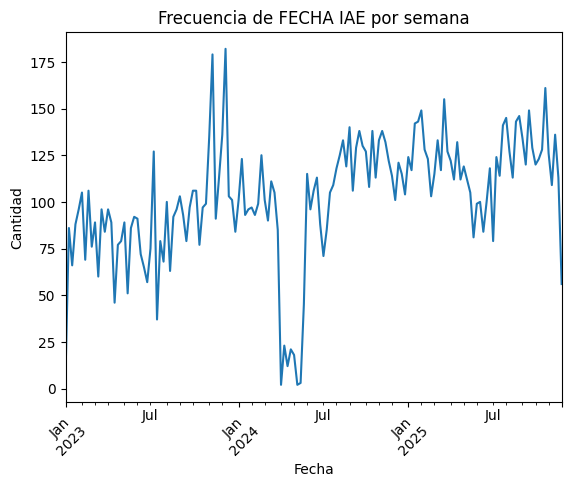

In [609]:
#df_IAE['FECHA IAE'].value_counts()
#conteo = df_IAE['REGISTRO'].dt.date.value_counts().sort_index() # por día
#conteo_semanal = df_IAE.set_index('FECHA IAE').resample('W').size()

#plt.figure()
#conteo_semanal.plot()
#plt.xlabel("Fecha")
#plt.ylabel("Cantidad")
#plt.title("Cantidad de intentos por semana")
#plt.xticks(rotation=45)
#plt.show()

graficar_segun_fecha(df_IAE, 'FECHA IAE', 'W')

In [610]:
mostrar_unicos(df_IAE,'METODO')
mostrar_frecuencias(df_IAE,'METODO')

METODO tiene 282 valores únicos.
['Lesiones autoinfligidas' 'Ingesta de Medicamentos' 'Otros'
 'Arma de fuego' 'Ahorcamiento o asfixia' nan '0'
 'EXPOSICI�N A FACTORES NO ESPECIFICADOS, QUE CAUSAN FRACTURA '
 'AHOGAMIENTO Y SUMERSI�N NO ESPECIFICADOS, CALLES Y CARRETERAS'
 'INHALACI�N DE CONTENIDOS G�STRICOS, INSTITUCI�N RESIDENCIAL'
 'EXPOSICI�N A CORRIENTE EL�CTRICA NO ESPECIFICADA, VIVIENDA'
 'LESI�N AUTOINFLIGIDA INTENCIONALMENTE POR AHORCAMIENTO, ESTRANGULAMIENTO O SOFOCACI�N VIVIENDA'
 'EXPOSICI�N A HUMOS, FUEGOS O LLAMAS NO ESPECIFICADOS, VIVIENDA'
 'OBSTRUCCI�N NO ESPECIFICADA DE LA RESPIRACI�N, LUGAR NO ESPECIFICADO'
 'OBSTRUCCI�N NO ESPECIFICADA DE LA RESPIRACI�N, VIVIENDA'
 'EXPOSICI�N A FACTORES NO ESPECIFICADOS QUE CAUSAN OTRAS LESIONES Y LAS NO ESPECIFICADAS '
 'ENVENENAMIENTO ACCIDENTAL POR, Y EXPOSICI�N AL ALCOHOL, LUGAR NO ESPECIFICADO'
 'EXPOSICI�N A FUEGO NO CONTROLADO EN EDIFICIO U OTRA CONSTRUCCI�N, VIVIENDA'
 'EVENTO NO ESPECIFICADO, DE INTENCI�N NO DETERMINADA, V

In [611]:
df_IAE['METODO'].value_counts().head(20)

METODO
Ingesta de Medicamentos                                                                                                   10916
Otros                                                                                                                      1446
Lesiones autoinfligidas                                                                                                    1333
Ahorcamiento o asfixia                                                                                                     1256
LESI�N AUTOINFLIGIDA INTENCIONALMENTE POR AHORCAMIENTO, ESTRANGULAMIENTO O SOFOCACI�N VIVIENDA                             1115
EXPOSICI�N A FACTORES NO ESPECIFICADOS, QUE CAUSAN FRACTURA                                                                 612
EXPOSICI�N A FACTORES NO ESPECIFICADOS QUE CAUSAN OTRAS LESIONES Y LAS NO ESPECIFICADAS                                     401
LESI�N AUTOINFLIGIDA INTENCIONALMENTE POR DISPARO DE OTRAS ARMAS DE FUEGO, Y LAS NO ESPECIFICADAS

In [612]:
df_IAE = acondicionar_atributo_metodo(df_IAE)

In [613]:
mostrar_frecuencias(df_IAE, 'METODO')

METODO
Ingesta de Medicamentos                                                                           10916
Ahorcamiento o asfixia                                                                             3066
Otros                                                                                              2523
Lesiones autoinfligidas                                                                            1551
Armas de fuego                                                                                      429
                                                                                                  ...  
OTROS EVENTOS ESPECIFICADOS, DE INTENCI�N NO DETERMINADA, INSTITUCI�N RESIDENCIAL                     1
EXPOSICIÓN A OTRAS FUERZAS MEC�NICAS INANIMADAS, Y LAS NO ESPECIFICADAS, LUGAR NO ESPECIFICADO        1
EXPLOSI�N Y ROTURA DE NEUM�TICO, TUBO O MANGUERA DE GOMA PRESURIZADA, CALLES Y CARRETERAS             1
PRIVACI�N DE ALIMENTOS, VIVIENDA                         

In [614]:
#categorias = ['Ingesta de Medicamentos', 'Ahorcamiento o asfixia','Lesiones autoinfligidas', 'Armas de fuego', 'Caída']
#df_IAE['METODO_'] = df_IAE['METODO'].where(df_IAE['METODO'].isin(categorias), 'Otros')
df_IAE = agregar_categoria_metodo(df_IAE)
mostrar_frecuencias(df_IAE, 'METODO_')

METODO_
Ingesta de Medicamentos    10916
Otros                       3725
Ahorcamiento o asfixia      3066
Lesiones autoinfligidas     1551
Armas de fuego               429
Caída                        184
Name: count, dtype: int64


In [615]:
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].str.strip() # Elimino espacios antes y después de los string
#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('IAE PREVIO','Tratamiento')
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].replace(palabras_a_reemplazar,'Tratamiento')
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].replace('Sin dato','NO SE INDICA')
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].replace('','NO SE INDICA')
#df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].fillna("NO SE INDICA")

mostrar_frecuencias(df_IAE,'IAE PREVIO')
df_IAE = acondicionar_IAE_PREVIO(df_IAE)
mostrar_frecuencias(df_IAE,'IAE PREVIO')
mostrar_unicos(df_IAE,'IAE PREVIO')

IAE PREVIO
SI                                                                                             7800
NO                                                                                             4824
NO SE INDICA                                                                                   2170
Tratamiento en el prestador habitual                                                            121
Sin dato                                                                                         33
NO                                                                                               10
SI                                                                                                8
Tratamiento en clínica privada                                                                    4
                                                                                                  1
Name: count, dtype: int64
IAE PREVIO
SI              7808
NO SE INDICA    7104
NO        

In [616]:
mostrar_valores_nulos(df_IAE,campo_nacimiento)

FECHA NACIMIENTO tiene 4826 valores nulos


In [617]:
#df_IAE['FECHA IAE'] = pd.to_datetime(df_IAE['FECHA IAE'], errors='coerce')
#df_IAE[campo_nacimiento] = pd.to_datetime(df_IAE[campo_nacimiento], errors='coerce')
#df_IAE['EDAD_'] = df_IAE['FECHA IAE'].dt.year - df_IAE[campo_nacimiento].dt.year
df_IAE = calcular_y_agregar_campo_edad(df_IAE, 'FECHA IAE', campo_nacimiento)
mostrar_rango(df_IAE, 'EDAD_')

El rango del atributo EDAD_ es [0.0, 113.0]


In [618]:
if dataset==1:
    coincidencias_edades = np.sum(df_IAE['EDAD_']==df_IAE['EDAD'])
    print(f'Coinciden {coincidencias_edades} de {len(df_IAE['EDAD_'])} edades')

In [619]:
campo_edad = 'EDAD_' if dataset==2 else 'EDAD' 
#edades_IAE = df_IAE[campo_edad].unique()
#print(edades_IAE)
#print(np.nanmin(edades_IAE), np.nanmax(edades_IAE))
#print(np.sum(np.isnan(edades_IAE)))
mostrar_unicos(df_IAE, campo_edad)
mostrar_rango(df_IAE, campo_edad)

EDAD_ tiene 98 valores únicos.
[ 14.  21.  17.  71.  27.  37.  53.  44.  32.  23.  49.  48.  82.  16.
  13.  24.  19.  63.  18.  25.  38.  41.  55.  33.  28.  20.  56.  47.
  15.  45.  35.  26.  62.  31.  58.  30.  61.  66.  29.  42.  52.  36.
  76.  nan  60.  54.  22.  12.  69.  34.   0.  65.  11.  39.  57.  77.
  67.  87.  43.  64.  46.  51.  86.  50.  40.  70.  59.  10.  73.  85.
  80.  79.  78.  72.  74.  84.   7.  68.  94.  89.  91.  81.  90. 103.
  88.  95.  98.  75.  83.   8.   9.  93.  96.  92.   2.   3. 113.   6.]
El rango del atributo EDAD_ es [0.0, 113.0]


In [620]:
df_IAE = discretizar(df_IAE, campo_edad, "GRUPO_EDAD_", 5)

In [621]:
# como esta columna contiene información del resultado (Suicidio o no), me quedan dudas de si es conveniente usarla para predecir. 
# Llama la aención la cantidad de casos en que no se cumple protocolo


#df_IAE[campo_decision] = df_IAE[campo_decision].str.strip() #saco espacios adelante y atras
#df_IAE[campo_decision].value_counts()

In [622]:
df_IAE = acondicionar_campo_DECISION(df_IAE, campo_decision)
mostrar_unicos(df_IAE, campo_decision)
mostrar_frecuencias(df_IAE, campo_decision)
#filas_unicas

DECISION tiene 13 valores únicos.
['NO CUMPLE PROTOCOLO' 'RESUELTO' 'PENDIENTE RESPUESTA' nan 'INTERNADO'
 'SIN COBERTURA ASISTENCIAL' 'SUICIDIO' 'SIN DATOS ASISTENCIALES'
 'RESPUESTA' 'PRIVADO DE LIBERTAD' 'RESUELT0'
 'FECHA ERRONEA DE IAE? UN AÑO ATRASO' 'SEG PARTICULAR']
DECISION
RESUELTO                               5887
NO CUMPLE PROTOCOLO                    2281
PENDIENTE RESPUESTA                    1360
INTERNADO                                68
SIN COBERTURA ASISTENCIAL                59
SUICIDIO                                 45
SIN DATOS ASISTENCIALES                   5
RESPUESTA                                 1
PRIVADO DE LIBERTAD                       1
RESUELT0                                  1
FECHA ERRONEA DE IAE? UN AÑO ATRASO       1
SEG PARTICULAR                            1
Name: count, dtype: int64


In [623]:
# se agrupan las decisiones

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'RESUELTO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'RESUELTO')

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'NO CUMPLE')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'NO CUMPLE PROTOCOLO')

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'SUICIDIO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'SUICIDIO')

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'INTERNAD')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'INTERNADO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace('INTERNADO ','INTERNADO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace('PENDIENTE INTERNADO','INTERNADO')

#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'PENDIENTE RESPUESTA')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'PENDIENTE RESPUESTA')
#palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'PENDEINTE RESPUESTA')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'PENDIENTE RESPUESTA')

#df_IAE[campo_decision] = df_IAE[campo_decision].replace('SIN RESPUESTA DEFINITIVA','PENDIENTE RESPUESTA')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace('SIN RESPUESTA','PENDIENTE RESPUESTA')


#df_IAE[campo_decision].unique()

In [624]:
# se crea una nueva columna DECISION_ con 6 categorías.
#df_IAE['DECISION_'] = df_IAE[campo_decision].copy()

#categorias = ['RESUELTO', 'NO CUMPLE PROTOCOLO','PENDIENTE RESPUESTA','INTERNADO', 'SUICIDIO']
#df_IAE['DECISION_'] = df_IAE['DECISION_'].where(df_IAE['DECISION_'].isin(categorias), 'OTRA DECISION')

agregar_campo_DECISION(df_IAE, campo_decision, 'DECISION_')
mostrar_unicos(df_IAE,campo_decision)
mostrar_frecuencias(df_IAE,campo_decision)
mostrar_unicos(df_IAE, 'DECISION_')
mostrar_frecuencias(df_IAE, 'DECISION_')

DECISION tiene 13 valores únicos.
['NO CUMPLE PROTOCOLO' 'RESUELTO' 'PENDIENTE RESPUESTA' nan 'INTERNADO'
 'SIN COBERTURA ASISTENCIAL' 'SUICIDIO' 'SIN DATOS ASISTENCIALES'
 'RESPUESTA' 'PRIVADO DE LIBERTAD' 'RESUELT0'
 'FECHA ERRONEA DE IAE? UN AÑO ATRASO' 'SEG PARTICULAR']
DECISION
RESUELTO                               5887
NO CUMPLE PROTOCOLO                    2281
PENDIENTE RESPUESTA                    1360
INTERNADO                                68
SIN COBERTURA ASISTENCIAL                59
SUICIDIO                                 45
SIN DATOS ASISTENCIALES                   5
RESPUESTA                                 1
PRIVADO DE LIBERTAD                       1
RESUELT0                                  1
FECHA ERRONEA DE IAE? UN AÑO ATRASO       1
SEG PARTICULAR                            1
Name: count, dtype: int64
DECISION_ tiene 6 valores únicos.
['NO CUMPLE PROTOCOLO' 'RESUELTO' 'PENDIENTE RESPUESTA' 'OTRA DECISION'
 'INTERNADO' 'SUICIDIO']
DECISION_
OTRA DECISION        

In [625]:
#df_IAE['IAE PREVIO'].value_counts()
mostrar_frecuencias(df_IAE, 'IAE PREVIO')
mostrar_unicos(df_IAE, 'IAE PREVIO')

IAE PREVIO
SI              7808
NO SE INDICA    7104
NO              4834
Tratamiento      125
Name: count, dtype: int64
IAE PREVIO tiene 4 valores únicos.
['NO SE INDICA' 'SI' 'NO' 'Tratamiento']


In [626]:
#df_IAE["DEFUNCION_"] = df_IAE["CEDULA"].isin(df_IAE_CDE["cedula"]).astype(int)
#print(np.sum(df_IAE["DEFUNCION_"])) # 309 intentos asociados a personas fallecidas
                                    # 4756 intentos asociados a personas fallecidas en la segunda entrega!!

df_IAE = agregar_si_intentos_en_CDE(df_IAE, df_IAE_CDE, 'IAE_en_CDE')                                    

Se agrego el campo IAE_en_CDE que vale 1 si la persona falleció (no necesariamente suicidio)
4756 de los 19871 intentos están asociados a personas fallecidas


In [627]:
df_IAE_CDE.head()

,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,estado_civil,etnia,mayor_nivel_educacion,institucion_fallecio,es_motivo_externo,motivo_externo,motivo_externo_desc,CAT_SUI_,CAT_MCEXSUI_,grupo edades_
0,0004278339f5f72aa648112ee2ea5968932e11d34147aa...,2025-08-06,X707,LESIÓN AUTOINFLIGIDA INTENCIONALMENTE POR AHOR...,OTRO,JURISDICCION DE SECCIONAL 12,AR,29.0,29.0,SOLTERO,BLANCA,SE DESCONOCE,NaN,S,SUICIDIO,ES ENCONTRADO EL CADÁVER COLGANDO DE UN ÁRBOL ...,1,0,27.5
1,0019b23cfe93768b7cdde4b1368e2b4b9591e64d5de3c1...,2024-04-21,Y260,"EXPOSICIÓN AL HUMO, FUEGO Y LLAMAS, DE INTENCI...",DOMICILIO,NaN,RV,NaN,64.0,SOLTERO,BLANCA,SE DESCONOCE,NaN,D,NaN,NaN,0,0,NaN
2,001da1f6d77a1a72835bba4c2b9d4ccdf297d90e00ada4...,2023-05-22,X849,LESIÓN AUTOINFLIGIDA INTENCIONALMENTE POR MEDI...,CENTRO ASISTENCIAL,NaN,MO,53.0,53.0,VIUDO,BLANCA,PRIMARIA COMPLETA,102.0,N,NaN,NaN,1,0,52.5
3,00238e5fe1190d87676fb70c58e36805b76e0e57e125b5...,2023-07-17,X599,EXPOSICIÓN A FACTORES NO ESPECIFICADOS QUE CAU...,CENTRO ASISTENCIAL,NaN,CL,85.0,85.0,CASADO,BLANCA,SE DESCONOCE,117.0,N,NaN,NaN,0,1,87.5
4,0023c61ba8506e99778380cfecdded0cadbac263fe9cdf...,2023-03-20,Y260,"EXPOSICIÓN AL HUMO, FUEGO Y LLAMAS, DE INTENCI...",OTRO,OTRO DOMICILIO,MO,26.0,26.0,SOLTERO,BLANCA,SE DESCONOCE,NaN,S,SE DESCONOCE,"Incendio en vivienda, se desconoce origen del ...",0,0,27.5


In [628]:
#df_IAE["FECHA_DEFUNCION"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["fecha_defuncion"])
#df_IAE["CAUSA_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["causa_basica_muerte_valor"])
#df_IAE["DPTO_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["departamento_ocurrencia"])
#df_IAE["EDAD_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["edad_fallecimiento_digitada"])
#df_IAE["GRUPO_EDAD_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["grupo edades"])
#df_IAE["MOTIVO_EXTERNO_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["motivo_externo"])
#df_IAE["MOTIVO_EXT_SUI_"] = df_IAE["MOTIVO_EXTERNO_"]=='SUICIDIO'
#df_IAE["ES_MOTIVO_EXTERNO_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["es_motivo_externo"])
#df_IAE["CAT_SUI_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["CAT_SUI_"])
#df_IAE["CAT_MCEXSUI_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["CAT_MCEXSUI_"])

df_IAE = agregar_datos_CDE_en_IAE(df_IAE, df_IAE_CDE, dataset)


In [629]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_', 'CDE_lugar_ocurrencia',
       'CDE_departamento_ocurrencia', 'CDE_estado_civil', 'CDE_etn

In [630]:
if dataset==2:
    mostrar_frecuencias(df_IAE, "MOTIVO_EXTERNO_")
    mostrar_frecuencias(df_IAE, "MOTIVO_EXT_SUI_")
    df_IAE.loc[df_IAE['PRESTADOR'].isnull(), 'IAE_en_CDE'].value_counts()
    df_IAE.loc[df_IAE['PRESTADOR_PRIVADO_'].isnull(), 'ES_MOTIVO_EXTERNO_'].value_counts()

MOTIVO_EXTERNO_
SUICIDIO        2171
ACCIDENTE        506
SE DESCONOCE     207
OTRO              42
HOMICIDIO          3
Name: count, dtype: int64
MOTIVO_EXT_SUI_
False    17700
True      2171
Name: count, dtype: int64


In [631]:
#df_IAE['IAE PREVIO'].value_counts()
mostrar_frecuencias(df_IAE, 'IAE PREVIO')

IAE PREVIO
SI              7808
NO SE INDICA    7104
NO              4834
Tratamiento      125
Name: count, dtype: int64


In [632]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_', 'CDE_lugar_ocurrencia',
       'CDE_departamento_ocurrencia', 'CDE_estado_civil', 'CDE_etn

In [633]:
if dataset==2:
    print(df_IAE[df_IAE['IAE PREVIO']=='NO SE INDICA']['ES_MOTIVO_EXTERNO_'].value_counts())
    print(df_IAE["CAT_SUI_"].sum(), df_IAE["CAT_MCEXSUI_"].sum(), df_IAE["IAE_en_CDE"].sum(), df_IAE["MOTIVO_EXTERNO_"].value_counts().sum())
    mostrar_valores_nulos(df_IAE, "CAT_SUI_")

ES_MOTIVO_EXTERNO_
S    2766
N    1529
D     103
Name: count, dtype: int64
2218.0 2073.0 4756 2929
CAT_SUI_ tiene 15115 valores nulos


In [634]:
if dataset==2:
    df_IAE = corregir_fechas_enteras_prestadores(df_IAE)
    df_IAE = acondicionar_campos_prestadores(df_IAE)
    df_IAE = acondicionar_CONCURRIO(df_IAE, 'CONCURRIO_', 'CONCURRIO_binaria')
    df_IAE = acondicionar_campo_agendo_consulta_en_7dias(df_IAE,'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO_')
    mostrar_frecuencias(df_IAE,'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO_')

En el campo FECHA SEGUIMIENTO se corrigieron 0 fechas enteras
En el campo FECHA LLAMADA PRESTADOR se corrigieron 0 fechas enteras
En el campo AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO se corrigieron 0 fechas enteras
En el campo FECHA DE CONSULTA se corrigieron 4900 fechas enteras
En el campo CONCURRIO se corrigieron 5516 fechas enteras
En el campo SE LLAMO A USUARIO Y/O REFERENTE se corrigieron 1 fechas enteras
En el campo AGENDO NUEVA CONSULTA se corrigieron 2 fechas enteras
En el campo FECHA DE NUEVA CONSULTA se corrigieron 312 fechas enteras
En el campo INTERNACION se corrigieron 617 fechas enteras
En el campo FECHA ALTA se corrigieron 2826 fechas enteras
En el campo FECHA LLAMADA PRESTADOR.1 se corrigieron 1149 fechas enteras
En el campo MSP se corrigieron 5820 fechas enteras
En el campo OBSERVACIONES se corrigieron 1 fechas enteras
En el campo UNNAMED: 26 se corrigieron 0 fechas enteras
En el campo FECHA DE LLAMADA AL PRESTADOR se corrigieron 44 fechas enteras
En el campo MOTIVO s

/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/utils.py:125: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<DatetimeArray>
['2023-04-05 00:00:00', '2023-07-03 00:00:00', '2023-07-14 00:00:00',
 '2023-12-27 00:00:00', '2024-12-26 00:00:00', '2025-08-21 00:00:00',
 '2025-08-13 00:00:00', '2023-02-22 00:00:00', '2023-05-05 00:00:00',
 '2023-03-10 00:00:00',
 ...
 '2023-05-29 00:00:00', '2023-06-07 00:00:00', '2023-03-09 00:00:00',
 '2023-02-16 00:00:00', '2023-04-11 00:00:00', '2023-05-19 00:00:00',
 '2023-04-10 00:00:00', '2023-04-12 00:00:00', '2023-06-09 00:00:00',
 '2023-08-10 00:00:00']
Length: 312, dtype: datetime64[ns]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  resultado[mask] = pd.to_datetime(
/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/utils.py:125: FutureWarning: Setting an item of incompatible dtype is depreca

AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO_
SI                            9130
NO                            3583
PENDIENTE RESPUESTA           1966
DESCARTADA_POR_RASTREADOR      275
INTERNADO                      185
NO CUMPLE PROTOCOLO             64
SUICIDIO                        56
SIN COBERTURA ASISTENCIAL       52
SEGUIMIENTO PARTICULAR          17
SIN DATO ASISTENCIAL             5
PRIVADO DE LIBERTAD              4
SIN REGISTRO                     2
                                 1
IAE CONSECUTIVO?                 1
DOBLE IAE ? 10/10 Y 11/10?       1
DOBLE IAE ? 29/09 Y 30/09?       1
Name: count, dtype: int64


/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/IAE.py:269: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  es_fecha = pd.to_datetime(df_IAE[nombre_campo], errors="coerce").notna()


In [635]:
if dataset==2:
    indices = df_IAE['FECHA LLAMADA PRESTADOR.1_'].isnull() * df_IAE['FECHA DE LLAMADA AL PRESTADOR_'].isnull()
    df_IAE.loc[~indices,['FECHA LLAMADA PRESTADOR.1_','FECHA DE LLAMADA AL PRESTADOR_', 'MSP_']].tail(30)

In [636]:
if dataset==2:
    mostrar_unicos(df_IAE,'FECHA LLAMADA PRESTADOR.1_')
    mostrar_unicos(df_IAE,'FECHA DE LLAMADA AL PRESTADOR_')
    mostrar_unicos(df_IAE,'MSP_')


FECHA LLAMADA PRESTADOR.1_ tiene 253 valores únicos.
[nan '2023-07-26 00:00:00' '2023-08-27 00:00:00' '2023-09-14 00:00:00'
 '17/09/2023 FUGA' '2023-10-03 00:00:00' '2023-10-06 00:00:00'
 '2023-10-11 00:00:00' '2023-10-20 00:00:00' '2023-10-17 00:00:00'
 '2023-10-19 00:00:00' '2023-10-27 00:00:00' '2023-10-13 00:00:00'
 '2023-10-14 00:00:00' '2023-10-21 00:00:00' '2023-10-22 00:00:00'
 '2023-11-14 00:00:00' '2023-10-02 00:00:00' '2023-10-16 00:00:00'
 '2023-10-23 00:00:00' '2023-10-31 00:00:00' '2023-11-07 00:00:00'
 '2023-10-24 00:00:00' '2023-10-25 00:00:00' '2023-10-26 00:00:00'
 '2023-11-03 00:00:00' '2023-11-29 00:00:00' '2023-11-01 00:00:00'
 '2023-11-06 00:00:00' '2023-11-20 00:00:00' '2023-10-30 00:00:00'
 '2023-12-12 00:00:00' '2023-11-10 00:00:00' '2023-10-28 00:00:00' 'SD'
 'SE FUGA' '2023-10-29 00:00:00' '2023-11-13 00:00:00' 'FUGA 27/10'
 'FUGA 28/10' '2023-11-02 00:00:00' 'SIGUE' 'PEND' '2023-11-04 00:00:00'
 '2023-11-17 00:00:00' '2023-11-11 00:00:00' '2023-11-09 00:00:0

In [637]:
if dataset==2:
    cambios = ~(df_IAE['FECHA DE CONSULTA'].eq(df_IAE['FECHA DE CONSULTA_']) |
                (df_IAE['FECHA DE CONSULTA'].isna() & df_IAE['FECHA DE CONSULTA_'].isna()))
    np.sum(cambios)

In [638]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_', 'CDE_lugar_ocurrencia',
       'CDE_departamento_ocurrencia', 'CDE_estado_civil', 'CDE_etn

In [639]:
if dataset==2:
    print(df_IAE['CONCURRIO'].unique().tolist())
    df_IAE['CONCURRIO_'] = convertir_enteros_a_fecha(df_IAE['CONCURRIO'])
    print(df_IAE['CONCURRIO_'].unique().tolist())

[nan, 'SI ', 'NO ', 'SI', 'NO', 'si', 'no', '45482', '45712', 'TELEFONICA', '45686', '45400', '45399', '45481', '45454', '45442', '45440', '45441', '30/0', '45448', '45439', '45446', '45447', '45443', '45449', '45456', '45444', '45694', '45469', '45455', '45474', '45467', '45450', '45468', '45451', '45453', '45461', '45457', '45460', '45471', '45452', '45550', '45477', '45463', '45506', '45693', '45462', '45553', '45437', '45476', '45490', '45458', '45464', '45486', '45470', '45483', '45500', '45465', '45478', '45484', '45475', '45466', '45533', '18/06/20254', '45485', '45502', '45540', '45516', '45489', '45523', '45488', '45492', '45499', '45503', '45495', '45497', '45504', '45496', '45519', '45509', '45505', '45498', '45527', '45653', '45511', '45512', '45525', '45541', '25/07/204 ', '45518', '45513', '45535', '45510', '45517', '45531', '45537', '45526', '45524', '45514', '45545', '45520', '45521', '45589', '45705', '09/08 PSIC', '45532', '45530', '45539', '45534', '45548', '45515', 

In [640]:
if dataset==2:
    print(df_IAE['AGENDO NUEVA CONSULTA'].unique().tolist())
    df_IAE['AGENDO NUEVA CONSULTA_'] = convertir_enteros_a_fecha(df_IAE['AGENDO NUEVA CONSULTA'])
    print(df_IAE['AGENDO NUEVA CONSULTA_'].unique().tolist())

['NO', 'SI ', nan, 'si', 'SI', 'NO ', 'no', 'pend ', '?', 'PEND', '45863', 'BRASIL', 'pend', 'pen', '45079', 'PEND ', 'PENDIENTE']
['NO', 'SI ', nan, 'si', 'SI', 'NO ', 'no', 'pend ', '?', 'PEND', Timestamp('2025-07-25 00:00:00'), 'BRASIL', 'pend', 'pen', Timestamp('2023-06-02 00:00:00'), 'PEND ', 'PENDIENTE']


In [641]:
df_IAE.columns

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_', 'CDE_lugar_ocurrencia',
       'CDE_departamento_ocurrencia', 'CDE_estado_civil', 'CDE_etn

In [642]:
if dataset==1:
    graficar_segun_fecha(df_IAE_CDE,'fecha_defuncion','W')

In [643]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19871 entries, 0 to 19883
Data columns (total 74 columns):
 #   Column                                      Non-Null Count  Dtype          
---  ------                                      --------------  -----          
 0   ID                                          15584 non-null  float64        
 1   CEDULA                                      19871 non-null  object         
 2   NOMBRE                                      0 non-null      float64        
 3   APELLIDO                                    0 non-null      float64        
 4   PERSONA                                     19340 non-null  object         
 5   FECHA NACIMIENTO                            15044 non-null  datetime64[ns] 
 6   DECISION                                    9710 non-null   object         
 7   PRESTADOR                                   15585 non-null  object         
 8   ESTABLECIMIENTO REGISTRO                    12496 non-null  object         
 9   

In [644]:
# días que transcurren desde el IAE hasta la muerte. Si la persona no murió se pone nan
#df_IAE['DIAS_IAE_MUERTE_'] = (df_IAE["FECHA_DEFUNCION"] - df_IAE["FECHA IAE"])
mostrar_frecuencias(df_IAE,'DIAS_IAE_MUERTE_')

DIAS_IAE_MUERTE_
0 days      15
2 days      12
4 days      10
9 days       7
1 days       7
            ..
901 days     1
214 days     1
685 days     1
587 days     1
106 days     1
Name: count, Length: 316, dtype: int64


In [645]:
df_IAE.loc[df_IAE['DIAS_IAE_MUERTE_'].dt.days<0, ['FECHA IAE', 'FECHA_DEFUNCION']]

,FECHA IAE,FECHA_DEFUNCION
12310,2023-05-03,2023-03-09
12688,2023-06-01,2023-02-12
12750,2023-09-04,2023-08-25
12848,2023-08-03,2023-07-28
13019,2023-11-05,2023-05-14
13149,2023-10-06,2023-09-05
13237,2023-11-02,2023-05-13
13240,2023-12-02,2023-06-04
13249,2023-12-03,2023-04-04
13325,2023-11-08,2023-09-28


In [646]:
#df_IAE['DIAS_IAE_MUERTE_'].unique()  # días transcurridos desde un IAE hasta muerte
mostrar_unicos(df_IAE,'DIAS_IAE_MUERTE_')

DIAS_IAE_MUERTE_ tiene 317 valores únicos.
<TimedeltaArray>
[       NaT, '227 days', '834 days', '405 days',  '21 days',  '26 days',
 '353 days',   '1 days',   '2 days', '543 days',
 ...
 '729 days', '617 days', '737 days', '614 days', '429 days', '901 days',
 '214 days', '685 days', '587 days', '106 days']
Length: 317, dtype: timedelta64[ns]


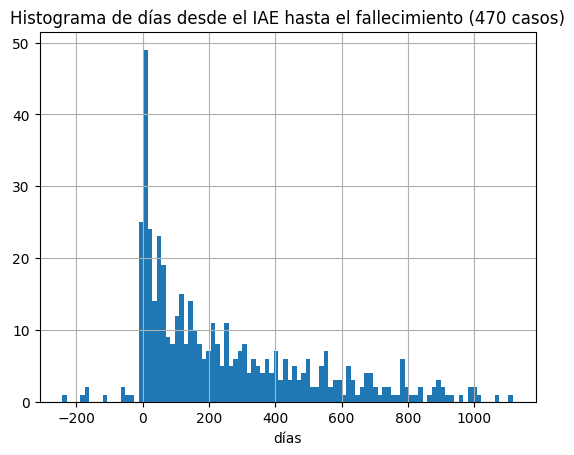

In [647]:
plt.figure()
df_IAE['DIAS_IAE_MUERTE_'].dt.days.hist(bins=100)
n_casos = df_IAE['DIAS_IAE_MUERTE_'].value_counts().sum()
plt.title(f'Histograma de días desde el IAE hasta el fallecimiento ({n_casos} casos)')
plt.xlabel('días')
plt.show()

In [648]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       'METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_', 'CDE_lugar_ocurrencia',
       'CDE_departamento_ocurrencia', 'CDE_estado_civil', 'CDE_etn

In [649]:
#for atributo in df_IAE.keys():
#    mostrar_valores_nulos(df_IAE,atributo)
#    mostrar_unicos(df_IAE,atributo)
#    mostrar_frecuencias(df_IAE,atributo)

In [650]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19871 entries, 0 to 19883
Data columns (total 74 columns):
 #   Column                                      Non-Null Count  Dtype          
---  ------                                      --------------  -----          
 0   ID                                          15584 non-null  float64        
 1   CEDULA                                      19871 non-null  object         
 2   NOMBRE                                      0 non-null      float64        
 3   APELLIDO                                    0 non-null      float64        
 4   PERSONA                                     19340 non-null  object         
 5   FECHA NACIMIENTO                            15044 non-null  datetime64[ns] 
 6   DECISION                                    9710 non-null   object         
 7   PRESTADOR                                   15585 non-null  object         
 8   ESTABLECIMIENTO REGISTRO                    12496 non-null  object         
 9   

In [651]:
if dataset==2:
    df_IAE.loc[indices_malos, 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO'].value_counts()

In [652]:
bad = df_IAE[df_IAE.isna().sum(axis=1) > 24]
bad.dropna(axis=1, how='all')

,ID,CEDULA,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,METODO,IAE PREVIO,...,FECHA ALTA_,FECHA LLAMADA PRESTADOR.1_,MSP_,OBSERVACIONES_,UNNAMED: 26_,FECHA DE LLAMADA AL PRESTADOR_,MOTIVO_,CONCURRIO_binaria,NO_CONCURRIO_CONSULTA_,DESCARTADA_POR_RASTREADOR
0,895.0,75b770ddbd1a43188f867d9ef8df0980412cb32b12374c...,Femenino,2009-09-01,NO CUMPLE PROTOCOLO,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,NaN,2023-01-24,Lesiones autoinfligidas,NO SE INDICA,...,NaN,NaN,VALENTINA ACOSTA,NaN,NaN,NaN,NaN,NaN,False,False
1,1507.0,f5138e15e53b4df18a439fd908b90d42c88c708280daac...,Femenino,2002-09-01,RESUELTO,CAMEC,NaN,2023-03-14,Ingesta de Medicamentos,SI,...,NaN,NaN,LIC ROMANO,,NaN,NaN,NaN,NaN,False,False
2,2677.0,919938e34174fd08e1fd49e678fc985160d058c6ea74d4...,Masculino,2006-05-01,RESUELTO,MEDICA URUGUAYA MUCAM,NaN,2023-06-08,Otros,SI,...,NaN,NaN,LIC ROMANO,DRA FERNANDEZ,NaN,NaN,NaN,SI,False,False
3,2804.0,6fb148c1f5d374e972746773f234955641ffee740f61f2...,Femenino,1952-07-01,PENDIENTE RESPUESTA,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO JUAN PABLO II,2023-06-19,Ingesta de Medicamentos,NO,...,NaN,NaN,VALENTINA ACOSTA,ENVIO EMAIL AL CIRCULO SOLICITANDO INFORMACION.,NaN,NaN,NaN,NaN,False,False
4,2805.0,182eafb797ccb4f8a55b932370740d5ab89093978223ae...,Femenino,1996-07-01,PENDIENTE RESPUESTA,CUDAM,CENTRAL,2023-06-19,Ingesta de Medicamentos,SI,...,NaN,NaN,VALENTINA ACOSTA,ME COMUNICO CON SUPERVISORA DE ARCHIVOS EN BUS...,NaN,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19879,NaN,ca22ff093b04f0c7b98744c37337fabce487dcefeaebf3...,Masculino,NaT,NaN,NaN,NaN,2025-01-28,Otros,NO SE INDICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
19880,NaN,c8426aa7f35f46523c1aded3048e5ca01179c5faf5131c...,Masculino,NaT,NaN,NaN,NaN,2025-02-18,Fuego,NO SE INDICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
19881,NaN,169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf4...,Masculino,NaT,NaN,NaN,NaN,2025-09-03,Fuego,NO SE INDICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
19882,NaN,fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1...,Femenino,NaT,NaN,NaN,NaN,2025-10-20,Fuego,NO SE INDICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False


# Análisis IAE CNV

In [653]:
df_IAE_CNV.shape

(5359, 27)

In [654]:
df_IAE_CNV.keys()

Index(['cedula', 'anio_mes_nacimiento_hijo', 'nro_rese', 'estado_civil',
       'pais_nac', 'pais_residencia', 'mayor_nivel_estudio', 'sexo', 'peso',
       'semanas_gestacion', 'orden', 'certdatospartocodocurrencia', 'apgar1',
       'apgar2', 'tipo_gesta', 'numero_embarazo_anteriores',
       'semana_embarazo_primer_consulta', 'total_consultas', 'mes_parto',
       'lugar_parto', 'lugar_depto', 'tipo_certificador', 'tipo_parto',
       'tipo_cesarea', 'forceps', 'vaccum', 'otra_maniobra'],
      dtype='object')

In [655]:
df_IAE_CNV.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5359 entries, 0 to 5358
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           5359 non-null   object        
 1   anio_mes_nacimiento_hijo         5359 non-null   datetime64[ns]
 2   nro_rese                         5359 non-null   object        
 3   estado_civil                     5359 non-null   object        
 4   pais_nac                         5359 non-null   object        
 5   pais_residencia                  5359 non-null   object        
 6   mayor_nivel_estudio              5359 non-null   object        
 7   sexo                             5359 non-null   object        
 8   peso                             5359 non-null   int64         
 9   semanas_gestacion                5359 non-null   int64         
 10  orden                            5359 non-null   int64      

In [656]:
#df_IAE_CNV=df_IAE_CNV.dropna(thresh=2) 
a = conservar_filas_con_n_no_nulos(df_IAE_CNV, 2)

La base tenía 5359 filas. Luego de eliminar las filas con al menos 2 campos nulos quedaron 5359 filas


In [657]:
df_IAE_CNV.shape

(5359, 27)

In [658]:
# Hay 41 duplicados
#df_IAE_CNV.drop_duplicates(inplace=True)
df_IAE_CNV = eliminar_duplicados(df_IAE_CNV)
df_IAE_CNV.shape

Se eliminaron 0 filas duplicadas en la base. Ahora la base tiene 5359 filas.


(5359, 27)

In [659]:
df_IAE_CNV_agrupada = df_IAE_CNV.groupby('cedula')

In [660]:
np.sum(df_IAE_CNV['cedula'].isnull())

np.int64(0)

In [661]:
grupo = df_IAE_CNV_agrupada.get_group('62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085')
grupo

,cedula,anio_mes_nacimiento_hijo,nro_rese,estado_civil,pais_nac,pais_residencia,mayor_nivel_estudio,sexo,peso,semanas_gestacion,...,total_consultas,mes_parto,lugar_parto,lugar_depto,tipo_certificador,tipo_parto,tipo_cesarea,forceps,vaccum,otra_maniobra
2749,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2017-10-01,37b4a66381ebbbc409a32c72e4b606ca0d949c581787b7...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2900,40,...,14.0,10.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0
2750,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2008-04-01,e7d4cfe19c14c154992dc5bdf4b819904f0e90568b9c64...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2420,37,...,9.0,4.0,1.0,MONTEVIDEO,MEDICO,VAGINAL,INTRAPARTO,0.0,0.0,0.0
2751,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2013-05-01,2dc74ac2cfb750ed27ca6c24ece46f833e22d0d5fd056c...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,3110,41,...,5.0,5.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0
2752,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2020-11-01,3e1f01b53df2685f0df404be47d6abf82be99d708dcc5e...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2180,38,...,12.0,11.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0
2753,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2011-09-01,afc5217fc784b883f588519206e6fffaf969f82a63b082...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,F,3120,38,...,9.0,9.0,1.0,MONTEVIDEO,MEDICO,VAGINAL,,0.0,0.0,0.0
2754,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2015-09-01,5172857a40eb4189e4e2517654882b048556964096f97b...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2420,37,...,6.0,9.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0


In [662]:
fecha_IAE = df_IAE[df_IAE['CEDULA']=='62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085']['FECHA IAE']
fecha_IAE

4064   2024-09-21
Name: FECHA IAE, dtype: datetime64[ns]

In [663]:
grupo['anio_mes_nacimiento_hijo'].values < fecha_IAE.values

array([ True,  True,  True,  True,  True,  True])

In [664]:
edad_hijo_mayor = (fecha_IAE - grupo['anio_mes_nacimiento_hijo'].max())
edad_hijo_mayor.dt.days/365.25

4064    3.887748
Name: FECHA IAE, dtype: float64

In [665]:
df_IAE = esta_persona_en_CNV(df_IAE_CNV, df_IAE)

if dataset==2:
    df_IAE = esta_nro_rese_en_IAE(df_IAE_CNV, df_IAE)

In [666]:
df_IAE_CNV.keys()

Index(['cedula', 'anio_mes_nacimiento_hijo', 'nro_rese', 'estado_civil',
       'pais_nac', 'pais_residencia', 'mayor_nivel_estudio', 'sexo', 'peso',
       'semanas_gestacion', 'orden', 'certdatospartocodocurrencia', 'apgar1',
       'apgar2', 'tipo_gesta', 'numero_embarazo_anteriores',
       'semana_embarazo_primer_consulta', 'total_consultas', 'mes_parto',
       'lugar_parto', 'lugar_depto', 'tipo_certificador', 'tipo_parto',
       'tipo_cesarea', 'forceps', 'vaccum', 'otra_maniobra'],
      dtype='object')

In [667]:
#df_IAE[["cantidad_hijos", "edad_hijo_mayor", "edad_hijo_menor"]] = df_IAE.apply( lambda row: agregar_datos_hijos_cuando_intento(row, df_IAE, df_IAE_CNV_agrupada), axis=1)
df_IAE = df_IAE.apply( lambda row: agregar_datos_hijos_cuando_intento(row, df_IAE_CNV_agrupada), axis=1)

In [668]:
if dataset==2:
    df_IAE = df_IAE.apply( lambda row: agregar_datos_CNV_cuando_intento(row, df_IAE_CNV_agrupada), axis=1)

In [669]:
df_IAE.keys()[10:]

Index(['METODO', 'IAE PREVIO', 'FECHA IAE', 'FECHA SEGUIMIENTO',
       'FECHA LLAMADA PRESTADOR', 'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO',
       'FECHA DE CONSULTA', 'CONCURRIO', 'SE LLAMO A USUARIO Y/O REFERENTE',
       'AGENDO NUEVA CONSULTA', 'FECHA DE NUEVA CONSULTA', 'INTERNACION',
       'FECHA ALTA', 'FECHA LLAMADA PRESTADOR.1', 'MSP', 'OBSERVACIONES',
       'UNNAMED: 26', 'FECHA DE LLAMADA AL PRESTADOR', 'MOTIVO',
       'tiene_registro_', 'es_IAE_', 'Tipo_prestador_IAE_',
       'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_', 'METODO_', 'EDAD_',
       'GRUPO_EDAD_', 'DECISION_', 'IAE_en_CDE', 'FECHA_DEFUNCION',
       'CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_', 'CDE_lugar_ocurrencia',
       'CDE_departamento_ocurrencia', 'CDE_estado_civil', 'CDE_etnia',
       'CDE_mayor_nivel_educacion', 'MOTIVO_EXTERNO_', 'MOTIVO_EXT_SUI_',
       'ES_MOTIVO_EXTERNO_', 'FECHA SEGUIMIENTO_', 'FECHA LLAMADA PRE

In [670]:
mostrar_valores_nulos(df_IAE,'CNV_edad_hijo_mayor_cuando_IAE')
mostrar_unicos(df_IAE,'CNV_edad_hijo_mayor_cuando_IAE')
mostrar_frecuencias(df_IAE,'CNV_edad_hijo_mayor_cuando_IAE')

CNV_edad_hijo_mayor_cuando_IAE tiene 16312 valores nulos
CNV_edad_hijo_mayor_cuando_IAE tiene 2595 valores únicos.
[        nan  8.37508556 12.30116359 ... 10.99247091  0.33127995
  0.41341547]
CNV_edad_hijo_mayor_cuando_IAE
11.321013    6
12.777550    6
12.002738    6
1.377139     5
12.804928    5
            ..
6.390144     1
4.720055     1
15.386721    1
4.479124     1
14.045175    1
Name: count, Length: 2594, dtype: int64


In [671]:
if dataset==2:
    mostrar_frecuencias(df_IAE,'CNV_ultimo_cuando_IAE_mayor_nivel_estudio')

CNV_ultimo_cuando_IAE_mayor_nivel_estudio
SECUNDARIA - CICLO BASICO    1337
SECUNDARIA - BACHILLERATO     612
                              595
PRIMARIA                      571
TERCIARIA - UNIVERSITARIA     280
DESCONOCIDO                   163
NINGUNO                         1
Name: count, dtype: int64


In [672]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19871 entries, 0 to 19883
Columns: 106 entries, ID to CNV_ultimo_cuando_IAE_otra_maniobra
dtypes: bool(5), datetime64[ns](5), float64(28), int64(3), object(64), timedelta64[ns](1)
memory usage: 16.1+ MB


In [673]:
if dataset==2:
    df_IAE.loc[~df_IAE['CNV_ultimo_cuando_IAE_cedula'].isnull(),['CEDULA', 'CNV_ultimo_cuando_IAE_cedula','CNV_ultimo_cuando_IAE_nro_rese']]


In [674]:
print(df_IAE.loc[df_IAE['CNV_cant_hijos_cuando_IAE']==6].to_string())

            ID                                                            CEDULA  NOMBRE  APELLIDO   PERSONA FECHA NACIMIENTO             DECISION                                                                  PRESTADOR                ESTABLECIMIENTO REGISTRO   REGISTRO                   METODO   IAE PREVIO  FECHA IAE    FECHA SEGUIMIENTO             FECHA LLAMADA PRESTADOR AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO FECHA DE CONSULTA CONCURRIO SE LLAMO A USUARIO Y/O REFERENTE AGENDO NUEVA CONSULTA  FECHA DE NUEVA CONSULTA INTERNACION FECHA ALTA FECHA LLAMADA PRESTADOR.1    MSP     OBSERVACIONES UNNAMED: 26 FECHA DE LLAMADA AL PRESTADOR  MOTIVO  tiene_registro_  es_IAE_ Tipo_prestador_IAE_ PRESTADOR_PUBLICO_ PRESTADOR_PRIVADO_                  METODO_  EDAD_  GRUPO_EDAD_            DECISION_  IAE_en_CDE FECHA_DEFUNCION CAUSA_MUERTE DPTO_MUERTE  EDAD_MUERTE  GRUPO_EDAD_MUERTE  CAT_SUI_  CAT_MCEXSUI_ DIAS_IAE_MUERTE_ CDE_lugar_ocurrencia CDE_departamento_ocurrencia CDE_estado_civil CDE_e

In [675]:
df_IAE[df_IAE['CEDULA']=='62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085']

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,CNV_ultimo_cuando_IAE_total_consultas,CNV_ultimo_cuando_IAE_mes_parto,CNV_ultimo_cuando_IAE_lugar_parto,CNV_ultimo_cuando_IAE_lugar_depto,CNV_ultimo_cuando_IAE_tipo_certificador,CNV_ultimo_cuando_IAE_tipo_parto,CNV_ultimo_cuando_IAE_tipo_cesarea,CNV_ultimo_cuando_IAE_forceps,CNV_ultimo_cuando_IAE_vaccum,CNV_ultimo_cuando_IAE_otra_maniobra
4064,8426.0,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,NaN,NaN,Femenino,1987-09-01,RESUELTO,CUDAM,SANATORIO COLON,2024-09-23,...,6.0,9.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0


In [676]:
# regionales de ASSE

In [677]:
df_IAE_CNV[df_IAE_CNV['cedula']=='62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085']

# cantidad de hijos
# edad más pequeño # ¿paridad completa?
# predecir reintento?

,cedula,anio_mes_nacimiento_hijo,nro_rese,estado_civil,pais_nac,pais_residencia,mayor_nivel_estudio,sexo,peso,semanas_gestacion,...,total_consultas,mes_parto,lugar_parto,lugar_depto,tipo_certificador,tipo_parto,tipo_cesarea,forceps,vaccum,otra_maniobra
2749,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2017-10-01,37b4a66381ebbbc409a32c72e4b606ca0d949c581787b7...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2900,40,...,14.0,10.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0
2750,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2008-04-01,e7d4cfe19c14c154992dc5bdf4b819904f0e90568b9c64...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2420,37,...,9.0,4.0,1.0,MONTEVIDEO,MEDICO,VAGINAL,INTRAPARTO,0.0,0.0,0.0
2751,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2013-05-01,2dc74ac2cfb750ed27ca6c24ece46f833e22d0d5fd056c...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,3110,41,...,5.0,5.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0
2752,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2020-11-01,3e1f01b53df2685f0df404be47d6abf82be99d708dcc5e...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2180,38,...,12.0,11.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0
2753,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2011-09-01,afc5217fc784b883f588519206e6fffaf969f82a63b082...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,F,3120,38,...,9.0,9.0,1.0,MONTEVIDEO,MEDICO,VAGINAL,,0.0,0.0,0.0
2754,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2015-09-01,5172857a40eb4189e4e2517654882b048556964096f97b...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2420,37,...,6.0,9.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0


In [678]:
mostrar_frecuencias(df_IAE_CNV,'cedula')

cedula
0e6c66043ed8cf01684ea1ffeb1b81b0d6096d18a63dca4fafdc47e8dc77f72e    7
44e39b19e5c363c4b37f1612ed72a5983ffc6b3dedee2ca57e8728c2598e3586    6
0d4942a8d9baba7f9f95c44c72db233281fcc987fecaa3858a44a68f82bbeb40    6
4864459a09c1d5ccb39caf4a87c17a19a8f344aaa3506fbe6a0bc4d3dfb31ccd    6
fc198870f88665e7c7867bee855b485f74c9f89bce2f1ab88e51937f9bbc301e    6
                                                                   ..
9044e99dfa7397bd517766dab1178b06934e65a734d7533e89f49e2081169a1c    1
6bc9a7046f53f17d1295ea09620cd829d80ee1d1b75fdc6be8cc1973eeef3aa3    1
89b56b020597ddb182c77ec7de8c24c18c965eebd6a94a36553ba12b7b3158db    1
79fede789ad1e666bf49303c4a2c4685c8601803f493dde21016fefc8dd91348    1
3293b157df5c85451c754d7889ec5f0f0ced72f84f7bb6d31bbb584785b0d68b    1
Name: count, Length: 3517, dtype: int64


In [679]:
df_IAE_CNV.keys()

Index(['cedula', 'anio_mes_nacimiento_hijo', 'nro_rese', 'estado_civil',
       'pais_nac', 'pais_residencia', 'mayor_nivel_estudio', 'sexo', 'peso',
       'semanas_gestacion', 'orden', 'certdatospartocodocurrencia', 'apgar1',
       'apgar2', 'tipo_gesta', 'numero_embarazo_anteriores',
       'semana_embarazo_primer_consulta', 'total_consultas', 'mes_parto',
       'lugar_parto', 'lugar_depto', 'tipo_certificador', 'tipo_parto',
       'tipo_cesarea', 'forceps', 'vaccum', 'otra_maniobra'],
      dtype='object')

In [680]:
df_IAE_CNV.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5359 entries, 0 to 5358
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           5359 non-null   object        
 1   anio_mes_nacimiento_hijo         5359 non-null   datetime64[ns]
 2   nro_rese                         5359 non-null   object        
 3   estado_civil                     5359 non-null   object        
 4   pais_nac                         5359 non-null   object        
 5   pais_residencia                  5359 non-null   object        
 6   mayor_nivel_estudio              5359 non-null   object        
 7   sexo                             5359 non-null   object        
 8   peso                             5359 non-null   int64         
 9   semanas_gestacion                5359 non-null   int64         
 10  orden                            5359 non-null   int64      

In [681]:
np.sum(df_IAE_CNV.duplicated())

np.int64(0)

In [682]:
df_IAE_CNV['anio_mes_nacimiento_hijo'].unique()

<DatetimeArray>
['2015-03-01 00:00:00', '2010-08-01 00:00:00', '2014-01-01 00:00:00',
 '2011-06-01 00:00:00', '2008-04-01 00:00:00', '2012-07-01 00:00:00',
 '2011-03-01 00:00:00', '2008-08-01 00:00:00', '2011-08-01 00:00:00',
 '2021-06-01 00:00:00',
 ...
 '2008-03-01 00:00:00', '2021-12-01 00:00:00', '2022-02-01 00:00:00',
 '2024-06-01 00:00:00', '2024-04-01 00:00:00', '2008-09-01 00:00:00',
 '2024-12-01 00:00:00', '2025-07-01 00:00:00', '2024-03-01 00:00:00',
 '2026-02-01 00:00:00']
Length: 216, dtype: datetime64[ns]

In [683]:
indices = df_IAE_CNV['cedula'].isin(df_IAE['CEDULA'])
personas_de_IAE_no_presentes_en_CNV = df_IAE_CNV[~indices]

In [684]:
df_IAE_CNV.keys()

Index(['cedula', 'anio_mes_nacimiento_hijo', 'nro_rese', 'estado_civil',
       'pais_nac', 'pais_residencia', 'mayor_nivel_estudio', 'sexo', 'peso',
       'semanas_gestacion', 'orden', 'certdatospartocodocurrencia', 'apgar1',
       'apgar2', 'tipo_gesta', 'numero_embarazo_anteriores',
       'semana_embarazo_primer_consulta', 'total_consultas', 'mes_parto',
       'lugar_parto', 'lugar_depto', 'tipo_certificador', 'tipo_parto',
       'tipo_cesarea', 'forceps', 'vaccum', 'otra_maniobra'],
      dtype='object')

In [685]:
if dataset==2:
    df_IAE_CNV['estado_civil']

In [686]:
#indices = df_IAE_CNV['cedula'].isin(df_IAE_agregada['CEDULA'])
#df_IAE_CNV[~indices].shape  # hay 20 cédulas que están en la base de CNV pero no están en la de IAE
                            # en la segunda entrega no hay cédulas que están en la base de CNV pero no están en la de IAE  
personas = personas_en_CNV_sin_IAE(df_IAE, df_IAE_CNV)                            

Hay 0 personas en CNV que no están en la base de IAE.


In [687]:
mostrar_frecuencias(df_IAE_CNV, 'cedula')

cedula
0e6c66043ed8cf01684ea1ffeb1b81b0d6096d18a63dca4fafdc47e8dc77f72e    7
44e39b19e5c363c4b37f1612ed72a5983ffc6b3dedee2ca57e8728c2598e3586    6
0d4942a8d9baba7f9f95c44c72db233281fcc987fecaa3858a44a68f82bbeb40    6
4864459a09c1d5ccb39caf4a87c17a19a8f344aaa3506fbe6a0bc4d3dfb31ccd    6
fc198870f88665e7c7867bee855b485f74c9f89bce2f1ab88e51937f9bbc301e    6
                                                                   ..
9044e99dfa7397bd517766dab1178b06934e65a734d7533e89f49e2081169a1c    1
6bc9a7046f53f17d1295ea09620cd829d80ee1d1b75fdc6be8cc1973eeef3aa3    1
89b56b020597ddb182c77ec7de8c24c18c965eebd6a94a36553ba12b7b3158db    1
79fede789ad1e666bf49303c4a2c4685c8601803f493dde21016fefc8dd91348    1
3293b157df5c85451c754d7889ec5f0f0ced72f84f7bb6d31bbb584785b0d68b    1
Name: count, Length: 3517, dtype: int64


In [688]:
df_IAE[df_IAE['CEDULA']=='89b56b020597ddb182c77ec7de8c24c18c965eebd6a94a36553ba12b7b3158db']

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,CNV_ultimo_cuando_IAE_total_consultas,CNV_ultimo_cuando_IAE_mes_parto,CNV_ultimo_cuando_IAE_lugar_parto,CNV_ultimo_cuando_IAE_lugar_depto,CNV_ultimo_cuando_IAE_tipo_certificador,CNV_ultimo_cuando_IAE_tipo_parto,CNV_ultimo_cuando_IAE_tipo_cesarea,CNV_ultimo_cuando_IAE_forceps,CNV_ultimo_cuando_IAE_vaccum,CNV_ultimo_cuando_IAE_otra_maniobra
19722,NaN,89b56b020597ddb182c77ec7de8c24c18c965eebd6a94a...,NaN,NaN,Masculino,NaT,NaN,NaN,NaN,2023-11-05,...,NaN,NaN,NaN,None,None,None,None,NaN,NaN,NaN


In [689]:
if dataset==2:
    mostrar_frecuencias(df_IAE_CNV, 'otra_maniobra')

otra_maniobra
0.0    3885
1.0       2
Name: count, dtype: int64


In [690]:
#df_IAE_CNV['anio_mes_nacimiento_hijo'].min(), df_IAE_CNV['anio_mes_nacimiento_hijo'].max()
mostrar_rango(df_IAE_CNV,'anio_mes_nacimiento_hijo')

El rango del atributo anio_mes_nacimiento_hijo es [2008-03-01 00:00:00, 2026-02-01 00:00:00]


In [691]:
df_IAE_CNV[df_IAE_CNV['cedula']=='0e6c66043ed8cf01684ea1ffeb1b81b0d6096d18a63dca4fafdc47e8dc77f72e']

,cedula,anio_mes_nacimiento_hijo,nro_rese,estado_civil,pais_nac,pais_residencia,mayor_nivel_estudio,sexo,peso,semanas_gestacion,...,total_consultas,mes_parto,lugar_parto,lugar_depto,tipo_certificador,tipo_parto,tipo_cesarea,forceps,vaccum,otra_maniobra
1409,0e6c66043ed8cf01684ea1ffeb1b81b0d6096d18a63dca...,2012-05-01,fcecc2f5c7c6adc3daf347e6d5c1c197664e902d8d12e3...,DESCONOCIDO,URUGUAY,URUGUAY,,M,3678,38,...,5.0,5.0,1.0,MONTEVIDEO,MEDICO,VAGINAL,,0.0,0.0,0.0
1410,0e6c66043ed8cf01684ea1ffeb1b81b0d6096d18a63dca...,2022-03-01,9f9be345a7a73e5383ed9a824ab93563af451a2d84b810...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,F,3670,40,...,8.0,3.0,1.0,MALDONADO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0
1411,0e6c66043ed8cf01684ea1ffeb1b81b0d6096d18a63dca...,2017-04-01,e9e4c297b6a875ac546dfc423a28b1d047ca009ca27f61...,SOLTERO/A,URUGUAY,URUGUAY,PRIMARIA,F,3020,38,...,3.0,4.0,1.0,MALDONADO,PARTERA,VAGINAL,,0.0,0.0,0.0
1412,0e6c66043ed8cf01684ea1ffeb1b81b0d6096d18a63dca...,2013-10-01,ea71be625c4881648beefdb7ef42c6dca9d0079d22260a...,SOLTERO/A,URUGUAY,URUGUAY,PRIMARIA,M,3170,40,...,4.0,10.0,1.0,ROCHA,PARTERA,VAGINAL,,0.0,0.0,0.0
1413,0e6c66043ed8cf01684ea1ffeb1b81b0d6096d18a63dca...,2011-04-01,3fb5ec4729c3509edfc62470fc826458a4a55655bad7e1...,SOLTERO/A,URUGUAY,URUGUAY,,M,3270,40,...,6.0,4.0,1.0,MONTEVIDEO,MEDICO,VAGINAL,,0.0,0.0,0.0
1414,0e6c66043ed8cf01684ea1ffeb1b81b0d6096d18a63dca...,2019-02-01,1cb2e0c6725fcc5920e219bc547e0b897fe57316a4f948...,CASADO/A,URUGUAY,URUGUAY,PRIMARIA,F,3390,40,...,10.0,2.0,1.0,MALDONADO,MEDICO,VAGINAL,,0.0,0.0,0.0
1415,0e6c66043ed8cf01684ea1ffeb1b81b0d6096d18a63dca...,2015-02-01,7dba9ae68d448d44c98cfaf66bfe773f04dba8168ec2f0...,SOLTERO/A,URUGUAY,URUGUAY,PRIMARIA,F,3560,40,...,6.0,2.0,1.0,MALDONADO,PARTERA,VAGINAL,,0.0,0.0,0.0


In [692]:
if dataset==2:
    df_IAE_CNV['nro_rese'].duplicated(False)

In [693]:
if dataset==2:
    print(df_IAE_CNV.loc[df_IAE_CNV['nro_rese']=='5822bae9958fa31035fe2d60b7325e394b1f84d9a8440c6da8cdb4724ae0ad53',['cedula']].to_string())

                                                                cedula
2673  3c58d4fabb5370ee7ff7aa8e5e8c472d03250004d49744131f8c0dff3d31acec
3295  c9061d6c64b76df0f672f58bf554bfa17b07e1ac049ba39c2a42cdc661023a0d


In [694]:
df_IAE[df_IAE['CEDULA']=='3c58d4fabb5370ee7ff7aa8e5e8c472d03250004d49744131f8c0dff3d31acec']

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,CNV_ultimo_cuando_IAE_total_consultas,CNV_ultimo_cuando_IAE_mes_parto,CNV_ultimo_cuando_IAE_lugar_parto,CNV_ultimo_cuando_IAE_lugar_depto,CNV_ultimo_cuando_IAE_tipo_certificador,CNV_ultimo_cuando_IAE_tipo_parto,CNV_ultimo_cuando_IAE_tipo_cesarea,CNV_ultimo_cuando_IAE_forceps,CNV_ultimo_cuando_IAE_vaccum,CNV_ultimo_cuando_IAE_otra_maniobra
15644,3189.0,3c58d4fabb5370ee7ff7aa8e5e8c472d03250004d49744...,NaN,NaN,Masculino,1993-03-01,NO CUMPLE PROTOCOLO,ASSE - HOSPITAL DE MINAS,HOSPITAL DE MINAS - Dr. Afredo Vidal y Fuentes,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [695]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       ...
       'CNV_ultimo_cuando_IAE_total_consultas',
       'CNV_ultimo_cuando_IAE_mes_parto', 'CNV_ultimo_cuando_IAE_lugar_parto',
       'CNV_ultimo_cuando_IAE_lugar_depto',
       'CNV_ultimo_cuando_IAE_tipo_certificador',
       'CNV_ultimo_cuando_IAE_tipo_parto',
       'CNV_ultimo_cuando_IAE_tipo_cesarea', 'CNV_ultimo_cuando_IAE_forceps',
       'CNV_ultimo_cuando_IAE_vaccum', 'CNV_ultimo_cuando_IAE_otra_maniobra'],
      dtype='object', length=106)

In [696]:
df_IAE_CNV.keys()

Index(['cedula', 'anio_mes_nacimiento_hijo', 'nro_rese', 'estado_civil',
       'pais_nac', 'pais_residencia', 'mayor_nivel_estudio', 'sexo', 'peso',
       'semanas_gestacion', 'orden', 'certdatospartocodocurrencia', 'apgar1',
       'apgar2', 'tipo_gesta', 'numero_embarazo_anteriores',
       'semana_embarazo_primer_consulta', 'total_consultas', 'mes_parto',
       'lugar_parto', 'lugar_depto', 'tipo_certificador', 'tipo_parto',
       'tipo_cesarea', 'forceps', 'vaccum', 'otra_maniobra'],
      dtype='object')

In [697]:
df_IAE_CNV.head()

,cedula,anio_mes_nacimiento_hijo,nro_rese,estado_civil,pais_nac,pais_residencia,mayor_nivel_estudio,sexo,peso,semanas_gestacion,...,total_consultas,mes_parto,lugar_parto,lugar_depto,tipo_certificador,tipo_parto,tipo_cesarea,forceps,vaccum,otra_maniobra
0,d96ca9598118b19feeddd7a74bdd4611ec63deb5f2d9cc...,2015-03-01,df115186afff6e1db45f77991d33825c2958e7d0533154...,DIVORCIADO/A,URUGUAY,URUGUAY,,M,670,29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,2010-08-01,1207c4e0d7db2964dd387d3ccfdbd39da33555720a8b54...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - BACHILLERATO,M,4000,39,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,63371439f928ce62b551eab4cad9388820dddda81e5e67...,2014-01-01,a3c2ced97df810230522617a9e354394b99093632066ab...,CASADO/A,URUGUAY,URUGUAY,SECUNDARIA - BACHILLERATO,F,2720,36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,018202e532a6c329b8c05ddccb458417faf63d24324c96...,2011-06-01,d6851c9a845ca5c04b10329aef220f1a5ab5413cc991e4...,CASADO/A,URUGUAY,URUGUAY,TERCIARIA - UNIVERSITARIA,M,3465,39,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cff897cefeaddcb9025fb2aaa1767f799637b84a578904...,2008-04-01,c21745ac849d3c991222ac64c70e92bb4e71e9fde53a53...,DIVORCIADO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,3460,40,...,5.0,4.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0


In [698]:
if dataset==2:
    df_IAE=incluir_otro_progrenitor(df_IAE,df_IAE_CNV)

/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/CNV.py:129: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_IAE["CNV_otro_progenitor_"] = df_IAE.merge(


In [699]:
df_IAE.head()

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,CNV_ultimo_cuando_IAE_mes_parto,CNV_ultimo_cuando_IAE_lugar_parto,CNV_ultimo_cuando_IAE_lugar_depto,CNV_ultimo_cuando_IAE_tipo_certificador,CNV_ultimo_cuando_IAE_tipo_parto,CNV_ultimo_cuando_IAE_tipo_cesarea,CNV_ultimo_cuando_IAE_forceps,CNV_ultimo_cuando_IAE_vaccum,CNV_ultimo_cuando_IAE_otra_maniobra,CNV_otro_progenitor_
0,895.0,75b770ddbd1a43188f867d9ef8df0980412cb32b12374c...,NaN,NaN,Femenino,2009-09-01,NO CUMPLE PROTOCOLO,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,NaN,2023-01-24,...,NaN,NaN,None,None,None,None,NaN,NaN,NaN,NaN
1,1507.0,f5138e15e53b4df18a439fd908b90d42c88c708280daac...,NaN,NaN,Femenino,2002-09-01,RESUELTO,CAMEC,NaN,2023-03-14,...,NaN,NaN,None,None,None,None,NaN,NaN,NaN,NaN
2,2677.0,919938e34174fd08e1fd49e678fc985160d058c6ea74d4...,NaN,NaN,Masculino,2006-05-01,RESUELTO,MEDICA URUGUAYA MUCAM,NaN,2023-06-08,...,NaN,NaN,None,None,None,None,NaN,NaN,NaN,NaN
3,2804.0,6fb148c1f5d374e972746773f234955641ffee740f61f2...,NaN,NaN,Femenino,1952-07-01,PENDIENTE RESPUESTA,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO JUAN PABLO II,2023-06-19,...,NaN,NaN,None,None,None,None,NaN,NaN,NaN,NaN
4,2805.0,182eafb797ccb4f8a55b932370740d5ab89093978223ae...,NaN,NaN,Femenino,1996-07-01,PENDIENTE RESPUESTA,CUDAM,CENTRAL,2023-06-19,...,12.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0,None


In [700]:
df_IAE_CNV.keys()

Index(['cedula', 'anio_mes_nacimiento_hijo', 'nro_rese', 'estado_civil',
       'pais_nac', 'pais_residencia', 'mayor_nivel_estudio', 'sexo', 'peso',
       'semanas_gestacion', 'orden', 'certdatospartocodocurrencia', 'apgar1',
       'apgar2', 'tipo_gesta', 'numero_embarazo_anteriores',
       'semana_embarazo_primer_consulta', 'total_consultas', 'mes_parto',
       'lugar_parto', 'lugar_depto', 'tipo_certificador', 'tipo_parto',
       'tipo_cesarea', 'forceps', 'vaccum', 'otra_maniobra'],
      dtype='object')

In [701]:
if dataset==2:
    (~df_IAE['CNV_otro_progenitor_'].isnull()).sum()

# Análisis IAE RUCAF

In [702]:
df_IAE_RUCAF.shape

(12199, 6)

In [703]:
'FF.AA' in df_IAE_RUCAF['prestador'].unique()[14]

True

In [704]:

#df_IAE_RUCAF=df_IAE_RUCAF.dropna(thresh=2) 
df_IAE_RUCAF = conservar_filas_con_n_no_nulos(df_IAE_RUCAF, 2)
df_IAE_RUCAF.shape

La base tenía 12199 filas. Luego de eliminar las filas con al menos 2 campos nulos quedaron 12199 filas


(12199, 6)

In [705]:
#df_IAE_RUCAF.drop_duplicates(inplace=True)  # no hay duplicados en RUCAF
df_IAE_RUCAF = eliminar_duplicados(df_IAE_RUCAF)
df_IAE_RUCAF.shape

Se eliminaron 0 filas duplicadas en la base. Ahora la base tiene 12199 filas.


(12199, 6)

In [706]:
df_IAE_RUCAF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12199 entries, 0 to 12198
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cedula        12199 non-null  object
 1   prestador     12199 non-null  object
 2   pais          12199 non-null  object
 3   departamento  12068 non-null  object
 4   localidad     11750 non-null  object
 5   cobertura     12199 non-null  object
dtypes: object(6)
memory usage: 572.0+ KB


In [707]:
mostrar_unicos(df_IAE_RUCAF,'localidad')
mostrar_unicos(df_IAE_RUCAF,'departamento')
mostrar_unicos(df_IAE_RUCAF,'pais')
mostrar_unicos(df_IAE_RUCAF,'cobertura')

localidad tiene 265 valores únicos.
['MONTEVIDEO' 'MALDONADO' 'SAN JOSE DE CARRASCO' 'DURAZNO' 'PAN DE AZUCAR'
 'BARROS BLANCOS' 'SAN JOSE DE MAYO' 'SALTO' 'TREINTA Y TRES' 'PAYSANDU'
 'CANELONES' 'LAS PIEDRAS' 'YOUNG' 'PIRIAPOLIS' nan 'BELLA UNION'
 'SANTA LUCIA' 'MINAS' 'NEPTUNIA' 'PANDO' 'VERGARA' 'MELO' 'PROGRESO'
 'ARTIGAS' 'MERCEDES' 'ECILDA PAULLIER' 'LIBERTAD'
 'DELTA DEL TIGRE Y VILLAS' 'CARMELO' 'SARANDI DEL YI' 'RIVERA'
 'CARRETA QUEMADA' 'FRAY BENTOS' 'CERRO PELADO' 'PINAMAR - PINEPARK'
 'SALINAS' 'TOLEDO' 'EL CHORRO' 'COLONIA DEL SACRAMENTO' 'DOLORES'
 'CUCHILLA ALTA' 'PALMITAS' 'BELEN' 'COLONIA VALDENSE' 'CERRILLOS'
 'SAN CARLOS' 'PUNTA DEL ESTE' 'CHUY' 'EL PINAR' 'TRANQUERAS' 'RIO BRANCO'
 'ROCHA' 'SANTA ROSA' 'LA CAPUERA' 'SAN JACINTO' 'EMPALME OLMOS'
 'PASO DE LOS TOROS' 'FLORIDA' 'COLONIA NICOLICH' 'TARARIRAS'
 'BOCA DEL ROSARIO' 'LA PAZ' 'BALTASAR BRUM' 'JAVIER DE VIANA' 'MIGUES'
 'RODRIGUEZ' 'TACUAREMBO' 'EL TESORO' 'MONTES' 'SAFICI (PARQUE POSTEL)'
 'RISSO' 'LA FLO

In [708]:
df_IAE_RUCAF.keys()

Index(['cedula', 'prestador', 'pais', 'departamento', 'localidad',
       'cobertura'],
      dtype='object')

In [709]:
df_IAE_RUCAF = agregar_tipo_prestador_IAE(df_IAE_RUCAF,'prestador','tipo_prestador_RUCAF')

In [710]:
df_IAE_RUCAF.keys()

Index(['cedula', 'prestador', 'pais', 'departamento', 'localidad', 'cobertura',
       'tipo_prestador_RUCAF', 'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_'],
      dtype='object')

In [711]:
df_IAE_RUCAF.head()

,cedula,prestador,pais,departamento,localidad,cobertura,tipo_prestador_RUCAF,PRESTADOR_PUBLICO_,PRESTADOR_PRIVADO_
0,d5dece3e533c269e6bb804be9c30ae691f022445351876...,ASOCIACIÓN ESPAÑOLA,UY,MONTEVIDEO,MONTEVIDEO,No Fonasa,Privada,False,True
1,92df4a0492d70e1f3290d6b96294afe0efbe9ee241055e...,UNIVERSAL,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True
2,49c383f277ff2654c9ee599ee802ed2e3b4e822be3451e...,ASSE,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,Pública,True,False
3,00e2527057fd9126b4c0346916628eaaf756aff82212c5...,ASSE,UY,MALDONADO,MALDONADO,Fonasa,Pública,True,False
4,8bef653aa6b2a0cbf932a4dc87746292f4ab52e62bf8cc...,SMI,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True


In [712]:
#indices = df_IAE_RUCAF['cedula'].isin(df_IAE_agregada['CEDULA'])
#df_IAE_RUCAF[~indices].shape 
personas_en_RUCAF_sin_IAE(df_IAE, df_IAE_RUCAF)

Hay 0 personas en RUCAF que no están en la base de IAE.


,cedula,prestador,pais,departamento,localidad,cobertura,tipo_prestador_RUCAF,PRESTADOR_PUBLICO_,PRESTADOR_PRIVADO_


In [713]:
#indices = df_IAE_procesada['CEDULA'].isin(df_IAE_RUCAF['cedula'])
#df_IAE_procesada[~indices].shape 

personas_con_IAE_no_presentes_en_RUCAF(df_IAE, df_IAE_RUCAF)

Hay 5399 personas con IAE no presentes en RUCAF.


,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,CNV_ultimo_cuando_IAE_mes_parto,CNV_ultimo_cuando_IAE_lugar_parto,CNV_ultimo_cuando_IAE_lugar_depto,CNV_ultimo_cuando_IAE_tipo_certificador,CNV_ultimo_cuando_IAE_tipo_parto,CNV_ultimo_cuando_IAE_tipo_cesarea,CNV_ultimo_cuando_IAE_forceps,CNV_ultimo_cuando_IAE_vaccum,CNV_ultimo_cuando_IAE_otra_maniobra,CNV_otro_progenitor_
13,2819.0,50aecb213f770a623e5e6f998c651ffa4d586cd1d151d5...,NaN,NaN,Femenino,1941-07-01,NaN,SERVICIO MEDICO INTEGRAL SMI,SANATORIO,2023-06-20,...,NaN,NaN,None,None,None,None,NaN,NaN,NaN,NaN
20,2828.0,653193e92e96dcb65baa9f7dd6c7db4929f795dd3e30e1...,NaN,NaN,Femenino,1960-11-01,NaN,CRAMI IAMPP,CRAMI - LAS PIEDRAS,2023-06-21,...,NaN,NaN,None,None,None,None,NaN,NaN,NaN,None
22,2830.0,f6c8126204b65cec380c817aafad30466cf3cb05063486...,NaN,NaN,Femenino,2005-04-01,NaN,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,CENTRO DE SALUD JARDINES DEL HIPODROMO,2023-06-21,...,NaN,NaN,None,None,None,None,NaN,NaN,NaN,NaN
29,2860.0,f078cc598271125c0d6c796f1ec0842df15b50f1a1ae6a...,NaN,NaN,Femenino,1985-10-01,RESUELTO,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,ITALIANO HOSPITAL,2023-06-26,...,9.0,1.0,MONTEVIDEO,MEDICO,VAGINAL,,0.0,0.0,0.0,NaN
33,644.0,00ec9c64d53ca761418f7bc5fa59e194ec3129b631a2b4...,NaN,NaN,Femenino,2007-07-01,NO CUMPLE PROTOCOLO,COMEPA,COMEPA,2023-09-12,...,NaN,NaN,None,None,None,None,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19879,NaN,ca22ff093b04f0c7b98744c37337fabce487dcefeaebf3...,NaN,NaN,Masculino,NaT,NaN,NaN,NaN,2025-01-28,...,NaN,NaN,None,None,None,None,NaN,NaN,NaN,NaN
19880,NaN,c8426aa7f35f46523c1aded3048e5ca01179c5faf5131c...,NaN,NaN,Masculino,NaT,NaN,NaN,NaN,2025-02-18,...,NaN,NaN,None,None,None,None,NaN,NaN,NaN,NaN
19881,NaN,169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf4...,NaN,NaN,Masculino,NaT,NaN,NaN,NaN,2025-09-03,...,NaN,NaN,None,None,None,None,NaN,NaN,NaN,NaN
19882,NaN,fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1...,NaN,NaN,Femenino,NaT,NaN,NaN,NaN,2025-10-20,...,NaN,NaN,None,None,None,None,NaN,NaN,NaN,NaN


In [714]:
mostrar_unicos(df_IAE_RUCAF,'pais')
mostrar_unicos(df_IAE_RUCAF,'departamento')

pais tiene 5 valores únicos.
['UY' 'PE' 'BR' 'AR' 'CU']
departamento tiene 20 valores únicos.
['MONTEVIDEO' 'MALDONADO' 'CANELONES' 'DURAZNO' 'SAN JOSE' 'SALTO'
 'TREINTA Y TRES' 'PAYSANDU' 'RIO NEGRO' 'RIVERA' 'ARTIGAS' 'LAVALLEJA'
 'CERRO LARGO' nan 'SORIANO' 'COLONIA' 'ROCHA' 'FLORES' 'TACUAREMBO'
 'FLORIDA']


In [715]:
df_IAE_RUCAF.keys()

Index(['cedula', 'prestador', 'pais', 'departamento', 'localidad', 'cobertura',
       'tipo_prestador_RUCAF', 'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_'],
      dtype='object')

In [716]:
df_IAE_RUCAF[df_IAE_RUCAF['cedula']=='95d3ecadc25d48ccd9a1f490058af05604baa1c61bca36fd88d0589784eae08c']

,cedula,prestador,pais,departamento,localidad,cobertura,tipo_prestador_RUCAF,PRESTADOR_PUBLICO_,PRESTADOR_PRIVADO_
2653,95d3ecadc25d48ccd9a1f490058af05604baa1c61bca36...,AMEDRIN COOPERATIVA MEDICA,UY,NaN,NaN,Fonasa,Privada,False,True


In [717]:
mostrar_frecuencias(df_IAE_RUCAF, 'cedula')

cedula
d92d63ca5a8faee9cd49e1bb29ab474d1962b9974c85f5c720570e6b9b328239    3
ab1f366bb87fcaaad7e3f39b0dae4d82c90bba5e7565af4ebe6539c70ef07e2b    3
2e11bbbb534e12b402aa2a6614c47e5d4dc5834e31574cf1e7f7a422fb881ba1    3
fdf4a55cb8a27cf39b92c544d8048e2f6a0ee9728697c9199f1dc6640ca8d30d    3
d79e023298b5c69587ff11f2e5ff7f8f02f2e1173bd7628c6b8b24085d094bdc    3
                                                                   ..
94d150deb0f96866c432a0a603154e8d3374c2e86cf9776f6d6e4e3f89959dfc    1
555dc04f2ad0b785ee84f01b50e861abd7c4259235c84d2f6ce60fda3294a75b    1
503fd0c51da396b86737bb911c95dd30eef1c3fae6c97f53ce304ebdfb8a8a28    1
55dfceb0d23166d3e27722b7f0eb12c2304f172507b73597415fa4638b03a237    1
272982b329fb477e6f2bad8c64da610312b33f992f7576152b2965a24e711d69    1
Name: count, Length: 11459, dtype: int64


In [718]:
#df_IAE_RUCAF_grouped = df_IAE_RUCAF.groupby('cedula').last()
#df_IAE_RUCAF_grouped = df_IAE_RUCAF_grouped.reset_index()

In [719]:
#df_IAE_RUCAF_grouped.head()

In [720]:

#df_IAE["RUCAF_prestador"] = df_IAE["CEDULA"].map(df_IAE_RUCAF_grouped.set_index("cedula")["prestador"])

In [721]:
df_IAE_RUCAF.keys()

Index(['cedula', 'prestador', 'pais', 'departamento', 'localidad', 'cobertura',
       'tipo_prestador_RUCAF', 'PRESTADOR_PUBLICO_', 'PRESTADOR_PRIVADO_'],
      dtype='object')

In [722]:
df_IAE = agregar_datos_RUCAF_en_IAE(df_IAE_RUCAF, df_IAE)

/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/RUCAF.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_IAE[f"RUCAF_{key}"] = df_IAE["CEDULA"].map(df_IAE_RUCAF_grouped.set_index("cedula")[key])
/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/RUCAF.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_IAE[f"RUCAF_{key}"] = df_IAE["CEDULA"].map(df_IAE_RUCAF_grouped.set_index("cedula")[key])
/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/RUCAF.py:11: PerformanceWarning: Da

In [723]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       ...
       'CNV_ultimo_cuando_IAE_otra_maniobra', 'CNV_otro_progenitor_',
       'RUCAF_prestador', 'RUCAF_pais', 'RUCAF_departamento',
       'RUCAF_localidad', 'RUCAF_cobertura', 'RUCAF_tipo_prestador_RUCAF',
       'RUCAF_PRESTADOR_PUBLICO_', 'RUCAF_PRESTADOR_PRIVADO_'],
      dtype='object', length=115)

In [724]:
indices =  ~df_IAE['PRESTADOR_PRIVADO_'].isnull() *  ~df_IAE['RUCAF_PRESTADOR_PRIVADO_'].isnull()
indices_distintos = df_IAE['PRESTADOR_PRIVADO_'] != df_IAE['RUCAF_PRESTADOR_PRIVADO_']
dif_prestadores = df_IAE.loc[ indices * indices_distintos,['CEDULA',campo_prestador,'PRESTADOR_PRIVADO_','PRESTADOR_PUBLICO_','RUCAF_prestador','RUCAF_PRESTADOR_PRIVADO_','RUCAF_PRESTADOR_PUBLICO_']]
dif_prestadores.to_csv(f'prestadores_diferentes_entrega_{dataset}_sin_agregar.csv')

In [725]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       ...
       'CNV_ultimo_cuando_IAE_otra_maniobra', 'CNV_otro_progenitor_',
       'RUCAF_prestador', 'RUCAF_pais', 'RUCAF_departamento',
       'RUCAF_localidad', 'RUCAF_cobertura', 'RUCAF_tipo_prestador_RUCAF',
       'RUCAF_PRESTADOR_PUBLICO_', 'RUCAF_PRESTADOR_PRIVADO_'],
      dtype='object', length=115)

In [726]:
df_IAE.head()

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,CNV_ultimo_cuando_IAE_otra_maniobra,CNV_otro_progenitor_,RUCAF_prestador,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,RUCAF_tipo_prestador_RUCAF,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_
0,895.0,75b770ddbd1a43188f867d9ef8df0980412cb32b12374c...,NaN,NaN,Femenino,2009-09-01,NO CUMPLE PROTOCOLO,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,NaN,2023-01-24,...,NaN,NaN,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True
1,1507.0,f5138e15e53b4df18a439fd908b90d42c88c708280daac...,NaN,NaN,Femenino,2002-09-01,RESUELTO,CAMEC,NaN,2023-03-14,...,NaN,NaN,CAMEC,UY,COLONIA,ROSARIO,No Fonasa,Privada,False,True
2,2677.0,919938e34174fd08e1fd49e678fc985160d058c6ea74d4...,NaN,NaN,Masculino,2006-05-01,RESUELTO,MEDICA URUGUAYA MUCAM,NaN,2023-06-08,...,NaN,NaN,MEDICA URUGUAYA,UY,CANELONES,PROGRESO,Fonasa,Privada,False,True
3,2804.0,6fb148c1f5d374e972746773f234955641ffee740f61f2...,NaN,NaN,Femenino,1952-07-01,PENDIENTE RESPUESTA,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO JUAN PABLO II,2023-06-19,...,NaN,NaN,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True
4,2805.0,182eafb797ccb4f8a55b932370740d5ab89093978223ae...,NaN,NaN,Femenino,1996-07-01,PENDIENTE RESPUESTA,CUDAM,CENTRAL,2023-06-19,...,0.0,None,CUDAM,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True


# Análisis IAE SHARPS

In [727]:
df_IAE_SHARPS.shape

(987, 2)

In [728]:
#df_IAE_SHARPS=df_IAE_SHARPS.dropna(thresh=2) 
df_IAE_SHARPS = conservar_filas_con_n_no_nulos(df_IAE_SHARPS, 2)
df_IAE_SHARPS.shape

La base tenía 987 filas. Luego de eliminar las filas con al menos 2 campos nulos quedaron 987 filas


(987, 2)

In [729]:
#indices = df_IAE_procesada['CEDULA'].isin(df_IAE_SHARPS['cedula'])
#df_IAE_procesada[~indices].shape 
personas_con_IAE_no_presentes_en_SHARPS(df_IAE, df_IAE_SHARPS)

Hay 18809 personas con IAE no presentes en SHARPS.


,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,CNV_ultimo_cuando_IAE_otra_maniobra,CNV_otro_progenitor_,RUCAF_prestador,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,RUCAF_tipo_prestador_RUCAF,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_
0,895.0,75b770ddbd1a43188f867d9ef8df0980412cb32b12374c...,NaN,NaN,Femenino,2009-09-01,NO CUMPLE PROTOCOLO,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,NaN,2023-01-24,...,NaN,NaN,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True
1,1507.0,f5138e15e53b4df18a439fd908b90d42c88c708280daac...,NaN,NaN,Femenino,2002-09-01,RESUELTO,CAMEC,NaN,2023-03-14,...,NaN,NaN,CAMEC,UY,COLONIA,ROSARIO,No Fonasa,Privada,False,True
2,2677.0,919938e34174fd08e1fd49e678fc985160d058c6ea74d4...,NaN,NaN,Masculino,2006-05-01,RESUELTO,MEDICA URUGUAYA MUCAM,NaN,2023-06-08,...,NaN,NaN,MEDICA URUGUAYA,UY,CANELONES,PROGRESO,Fonasa,Privada,False,True
3,2804.0,6fb148c1f5d374e972746773f234955641ffee740f61f2...,NaN,NaN,Femenino,1952-07-01,PENDIENTE RESPUESTA,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO JUAN PABLO II,2023-06-19,...,NaN,NaN,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True
4,2805.0,182eafb797ccb4f8a55b932370740d5ab89093978223ae...,NaN,NaN,Femenino,1996-07-01,PENDIENTE RESPUESTA,CUDAM,CENTRAL,2023-06-19,...,0.0,None,CUDAM,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19879,NaN,ca22ff093b04f0c7b98744c37337fabce487dcefeaebf3...,NaN,NaN,Masculino,NaT,NaN,NaN,NaN,2025-01-28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19880,NaN,c8426aa7f35f46523c1aded3048e5ca01179c5faf5131c...,NaN,NaN,Masculino,NaT,NaN,NaN,NaN,2025-02-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19881,NaN,169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf4...,NaN,NaN,Masculino,NaT,NaN,NaN,NaN,2025-09-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19882,NaN,fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1...,NaN,NaN,Femenino,NaT,NaN,NaN,NaN,2025-10-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [730]:
df_IAE_SHARPS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 987 entries, 0 to 986
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cedula  987 non-null    object
 1   titulo  987 non-null    object
dtypes: object(2)
memory usage: 15.6+ KB


In [731]:
df_IAE_SHARPS.titulo

0      LICENCIADO EN PSICOLOGIA                      ...
1      LICENCIADO EN IMAGENOLOGIA                    ...
2      TECNICO EN HEMOTERAPIA                        ...
3      AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
4      AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
                             ...                        
982    AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
983    AUXILIAR DE SERVICIO, TISANERIA Y AYUDANTE DE ...
984    AUXILIAR DE ENFERMERÍA INTEGRAL               ...
985    AUXILIAR DE ENFERMERÍA                        ...
986    AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
Name: titulo, Length: 987, dtype: object

In [732]:
#np.sum(df_IAE_SHARPS.duplicated())
mostrar_duplicados(df_IAE_SHARPS)

La base tiene 0 filas duplicadas


In [733]:
len(df_IAE_SHARPS['cedula'].unique())

848

In [734]:
mostrar_frecuencias(df_IAE_SHARPS, 'cedula')

cedula
aafd79a9599ed0f894616fd5351d2cd47a793be543085917252333e25259a7bf    5
03271954bc341c343c563801cf59e441842798d7ff598fdb289f79d4ea07953c    4
1daf35995e63a6b761c5cb3e8fa5563ea20a2367f8e89538329c660872eea4ef    4
a2073562f82d2006d3d75b4839f391ebee1a0f08b3b6e82aa0daa146df296522    3
84172b1677f145c5805bf33790c393ffaf56c93a49977f4c2f7cff8d3516413b    3
                                                                   ..
5ee48898e88522c2220750b4656389773e945368ac93f4eec9253afa30daf176    1
5ee6f9611ede1241ff194b82a8b3e0769cc06be79aae94a88723a69a630d88b3    1
5f0e2d0f47663d9d66b0189c4b95cde49fc5501c7295f5c0968554f2c8647ff8    1
5fb1e2b81df792517253355a461c71950f21d8bcc8857b4274932eb938ab1ae3    1
5ca0570d59abc7575bc00cb9b3c3cea15860e806aacbfda8c7decda78edd6942    1
Name: count, Length: 848, dtype: int64


In [735]:
df_IAE = esta_persona_en_SHARPS(df_IAE_SHARPS, df_IAE)

/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/SHARP.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_IAE["SHARPS_"] = df_IAE["CEDULA"].isin(df_SHARPS["cedula"]).astype(int)


# Análisis IAE SIV

In [736]:
df_IAE_SIV.shape

(206117, 4)

In [737]:
#df_IAE_SIV=df_IAE_SIV.dropna(thresh=2) 
#df_IAE_SIV.shape
df_IAE_SIV = conservar_filas_con_n_no_nulos(df_IAE_SIV, 2)

La base tenía 206117 filas. Luego de eliminar las filas con al menos 2 campos nulos quedaron 206117 filas


In [738]:
#np.sum(df_IAE_SIV.duplicated())  # hay 231 duplicados en esta base
df_IAE_SIV = eliminar_duplicados(df_IAE_SIV)

Se eliminaron 0 filas duplicadas en la base. Ahora la base tiene 206117 filas.


In [739]:
df_IAE_SIV.shape

(206117, 4)

In [740]:
#indices = df_IAE_SIV['cedula'].isin(df_IAE_procesada['CEDULA'])  # 201 casos están en la base SIV pero no en la de IAE
#df_IAE_SIV[~indices]

personas_en_SIV_sin_IAE(df_IAE, df_IAE_SIV)

Hay 0 personas en SIV que no están en la base de IAE.


,cedula,fecha,descripcion,dosis


In [741]:
mostrar_frecuencias(df_IAE_SIV,'descripcion')

descripcion
ANTIPOLIOMELÍTICA (VPO)                              28662
COVID 19 - PFIZER-BIONTECH                           28010
PENTAVALENTE (DPT,HB/Hib)                            19406
TRIPLE BACTERIANA (Difteria,Tétanos,Tos convulsa)    16687
TRIPLE VIRAL (Sarampión,Rubeola,Paperas)             14538
                                                     ...  
MENINGOCOCO A+C                                          2
ROTAVIRUS 1S                                             2
COVID 19 - SPUTNIK V                                     1
HEPATITIS A Y FIEBRE TIFOIDEA                            1
DOBLE VIRAL (SR)                                         1
Name: count, Length: 65, dtype: int64


In [742]:
df_IAE_SIV.head()

,cedula,fecha,descripcion,dosis
0,0000e681952be7f20878a73707231609bf41c5c8c0a86b...,2021-03-29,COVID 19 - CORONAVAC,1
1,0000e681952be7f20878a73707231609bf41c5c8c0a86b...,2021-04-26,COVID 19 - CORONAVAC,2
2,0000e681952be7f20878a73707231609bf41c5c8c0a86b...,2021-09-07,COVID 19 - PFIZER-BIONTECH,3
3,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,2008-02-27,BCG,1
4,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,2008-04-28,ANTINEUMOCÓCICA CONJUGADA 7,1


In [743]:
df_IAE_SIV.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206117 entries, 0 to 206116
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   cedula       206117 non-null  object        
 1   fecha        206117 non-null  datetime64[ns]
 2   descripcion  206117 non-null  object        
 3   dosis        206117 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 6.3+ MB


In [744]:
np.sum(df_IAE_SIV.duplicated())

np.int64(0)

In [745]:
df_IAE_SIV.cedula.value_counts()

cedula
902a99871d14696073b4c2314fbaa822aea95ef3cffe19ebaae5168919e3e0a1    42
24882918a56db014b63afa8aef1bc3c74ee9aa3daf60151b893ee7384716c639    39
39a3a215244cbeaa30a338cb5d3d0ee321f301be97bb02a7aca4ef350cabbedd    37
f6c8b6034f539dc2bba8cd6961b369bf19d0dbe3488e067d20ff222c6c377e6f    36
e085b0fffca1ade684568be040784deb9333a17afedd7022e1c996c3b6e221e2    36
                                                                    ..
8ed8a208de57785688958bc3e85dd2e8f6c9b7e75a70cc55b6be5881eb5ac305     1
f9685febd6e824a239236e252b499d751b230d46d34f431a120e5378ad1747cd     1
75b122a1b5d3b9ea4dc7291644a55176a955a14da7a7fec6b7dda4c8d38077f7     1
0508064c7f183f81ebcb57d99588f243aa91c3f16242b53c2b3d0f521fee2831     1
d8f34bc652ee3e5b3a32fdacfd4cc83ef5f026ed7dec5dce88883dbefbe7de51     1
Name: count, Length: 16125, dtype: int64

In [746]:
len(df_IAE_SIV.cedula.unique())

16125

In [747]:
df_IAE_SIV.descripcion.value_counts()

descripcion
ANTIPOLIOMELÍTICA (VPO)                              28662
COVID 19 - PFIZER-BIONTECH                           28010
PENTAVALENTE (DPT,HB/Hib)                            19406
TRIPLE BACTERIANA (Difteria,Tétanos,Tos convulsa)    16687
TRIPLE VIRAL (Sarampión,Rubeola,Paperas)             14538
                                                     ...  
MENINGOCOCO A+C                                          2
ROTAVIRUS 1S                                             2
COVID 19 - SPUTNIK V                                     1
HEPATITIS A Y FIEBRE TIFOIDEA                            1
DOBLE VIRAL (SR)                                         1
Name: count, Length: 65, dtype: int64

In [748]:
df_IAE = agregar_campos_SIV(df_IAE_SIV, df_IAE)

/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/SIV.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_IAE["SIV_"] = df_IAE["CEDULA"].isin(df_SIV["cedula"]).astype(int)
/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/SIV.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_base[nombre_col] = df_base['CEDULA'].map(df_agg['dosis'])
/home/carbajal/Documents/SaludMental/codigo_solucionadores/utils/SIV.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of ca

In [749]:
df_IAE['ANTIPOLIOMELITICA'].info()

<class 'pandas.core.series.Series'>
Index: 19871 entries, 0 to 19883
Series name: ANTIPOLIOMELITICA
Non-Null Count  Dtype  
--------------  -----  
9774 non-null   float64
dtypes: float64(1)
memory usage: 826.5 KB


In [750]:
df_IAE['COVID 19'].info()

<class 'pandas.core.series.Series'>
Index: 19871 entries, 0 to 19883
Series name: COVID 19
Non-Null Count  Dtype  
--------------  -----  
17134 non-null  float64
dtypes: float64(1)
memory usage: 826.5 KB


In [751]:
df_IAE_SIV[df_IAE_SIV['cedula']=='d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abbdc0141510adef16dd2']

,cedula,fecha,descripcion,dosis
174208,d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abb...,1999-09-25,BCG,1
174209,d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abb...,1999-11-24,ANTIPOLIOMELÍTICA (VPO),1
174210,d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abb...,1999-11-24,HEPATITIS B ADULTOS,1
174211,d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abb...,1999-11-24,Hib,1
174212,d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abb...,1999-11-24,"TRIPLE BACTERIANA (Difteria,Tétanos,Tos convulsa)",1
174213,d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abb...,2000-02-18,ANTIPOLIOMELÍTICA (VPO),2
174214,d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abb...,2000-02-18,HEPATITIS B ADULTOS,2
174215,d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abb...,2000-02-18,Hib,2
174216,d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abb...,2000-02-18,"TRIPLE BACTERIANA (Difteria,Tétanos,Tos convulsa)",2
174217,d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abb...,2000-05-19,ANTIPOLIOMELÍTICA (VPO),3


In [752]:
print(df_IAE.loc[df_IAE['COVID 19'].isnull(),['CEDULA','COVID 19']].to_string())

                                                                 CEDULA  COVID 19
17     aa27201c4b561a4e97001b54db62457ef4edecf6ea85f14ed7a8a7615d372afe       NaN
36     924e6f51158b930d08cff8484a154621674c49bbb7232c152a19554cdcbcde96       NaN
42     75288648e87d4f6b5fa7461953f52be1fedad99b029a91405b978ced58cd1333       NaN
55     c1c81c5eaa0ce057ab37cf74907c4abe15be1abfe2d8b440ee8f2640710564b3       NaN
77     716015afad7ba8d545ff9179dea124c30dd96e9993c9b1c207de5b12ce86c2f2       NaN
78     00dfb60c967279ed9bdce167d59016c4e527310f5edf8c21d79572e945fc9167       NaN
82     d8507d0f863ad08baa572b03f2be31c5aadf7ce6183abbdc0141510adef16dd2       NaN
97     650fe016fbef355061b589a6033709456f8ff3f4dd1d8a52d6d135c4b7b93953       NaN
101    1855d9d2026cbc24e7be1c1ba13bc166b04da5f0429796d5f416c56165cfd8e6       NaN
102    2865c7f3e4c991c682af5fac1b54f9835b9e050457941e2a230952489b03a5d7       NaN
107    c4cf420bd8a7f112a0660f64a1c67773b0c8199b23e68979f3f2cbd0de610480       NaN
108    12624e21c

In [753]:
df_IAE.head(10)

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,RUCAF_tipo_prestador_RUCAF,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_,SHARPS_,SIV_,ANTIPOLIOMELITICA,COVID 19
0,895.0,75b770ddbd1a43188f867d9ef8df0980412cb32b12374c...,NaN,NaN,Femenino,2009-09-01,NO CUMPLE PROTOCOLO,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,NaN,2023-01-24,...,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True,0,1,4.0,2.0
1,1507.0,f5138e15e53b4df18a439fd908b90d42c88c708280daac...,NaN,NaN,Femenino,2002-09-01,RESUELTO,CAMEC,NaN,2023-03-14,...,COLONIA,ROSARIO,No Fonasa,Privada,False,True,0,1,4.0,3.0
2,2677.0,919938e34174fd08e1fd49e678fc985160d058c6ea74d4...,NaN,NaN,Masculino,2006-05-01,RESUELTO,MEDICA URUGUAYA MUCAM,NaN,2023-06-08,...,CANELONES,PROGRESO,Fonasa,Privada,False,True,0,1,4.0,2.0
3,2804.0,6fb148c1f5d374e972746773f234955641ffee740f61f2...,NaN,NaN,Femenino,1952-07-01,PENDIENTE RESPUESTA,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO JUAN PABLO II,2023-06-19,...,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True,0,1,NaN,3.0
4,2805.0,182eafb797ccb4f8a55b932370740d5ab89093978223ae...,NaN,NaN,Femenino,1996-07-01,PENDIENTE RESPUESTA,CUDAM,CENTRAL,2023-06-19,...,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True,0,1,4.0,3.0
5,2806.0,8b2d55e33d23be0a107b9f7a07c61677644face1cc4c99...,NaN,NaN,Masculino,2006-02-01,RESUELTO,CASMU,SANATORIO 2 Urgencia,2023-06-19,...,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True,0,1,4.0,2.0
6,2807.0,4bdc5c6070127b6e1d7489f67c031835f179ab49e39c7b...,NaN,NaN,Femenino,1986-05-01,NO CUMPLE PROTOCOLO,CASMU,SANATORIO 2 Urgencia,2023-06-19,...,MONTEVIDEO,MONTEVIDEO,No Fonasa,Pública,True,False,0,1,NaN,1.0
7,2808.0,d7926d9d7496ad7b7eac19765e82542f377fe1ffdc9ae0...,NaN,NaN,Masculino,1970-06-01,NO CUMPLE PROTOCOLO,CASMU,SANATORIO 2 Urgencia,2023-06-19,...,MONTEVIDEO,MONTEVIDEO,Fonasa,Privada,False,True,0,1,3.0,2.0
8,2809.0,42460f068be30099444b41e1a3a8913c40b4117a5524c1...,NaN,NaN,Femenino,1979-05-01,NaN,ASSE - MONTEVIDEO | DIRECCION NACIONAL DE SANI...,(Sin institución),2023-06-20,...,MONTEVIDEO,MONTEVIDEO,No Fonasa,Pública,True,False,1,1,NaN,3.0
9,2813.0,a919828d10f070622187ad57155d808e9dec379a9932c0...,NaN,NaN,Masculino,1991-10-01,NaN,ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DE...,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,2023-06-20,...,RIVERA,RIVERA,No Fonasa,Pública,True,False,0,1,NaN,2.0


In [754]:
df_IAE_SIV.descripcion.unique()

array(['COVID 19 - CORONAVAC', 'COVID 19 - PFIZER-BIONTECH', 'BCG',
       'ANTINEUMOCÓCICA CONJUGADA 7', 'ANTIPOLIOMELÍTICA (VPO)',
       'PENTAVALENTE (DPT,HB/Hib)',
       'TRIPLE VIRAL (Sarampión,Rubeola,Paperas)', 'VARICELA',
       'HEPATITIS A PEDIATRICA',
       'TRIPLE BACTERIANA (Difteria,Tétanos,Tos convulsa)',
       'TRIPLE BACTERIANA ACELULAR (dpaT)',
       'VPH - VIRUS PAPILOMA HUMANO (4 GENOTIPOS)',
       'DOBLE BACTERIANA ADULTOS (Difteria-Tétanos)', 'ANTIGRIPAL 2019',
       'HEPATITIS B ADULTOS', 'ANTIGRIPAL 2022',
       'ANTIGRIPAL TRIVALENTE 2023', 'Hib', 'ANTIGRIPAL',
       'ANTIPOLIOMELÍTICA INACTIVADA (VPI) - SALK', 'FIEBRE AMARILLA',
       'HEPATITIS A ADULTOS', 'ANTIGRIPAL TRIVALENTE 2024',
       'ANTIGRIPAL 2020', 'ANTIGRIPAL 2021', 'ANTIGRIPAL 2018',
       'ANTIGRIPAL TRIVALENTE 2025', 'ANTINEUMOCÓCICA CONJUGADA 13',
       'HEPATITIS B PEDIÁTRICA', 'ANTINEUMOCÓCICA 23',
       'RABIA POST-EXPOSICIÓN', 'COVID 19 - ASTRAZENECA',
       'HEPATITIS A Y\

In [755]:
mostrar_frecuencias(df_IAE_SIV, 'descripcion')

descripcion
ANTIPOLIOMELÍTICA (VPO)                              28662
COVID 19 - PFIZER-BIONTECH                           28010
PENTAVALENTE (DPT,HB/Hib)                            19406
TRIPLE BACTERIANA (Difteria,Tétanos,Tos convulsa)    16687
TRIPLE VIRAL (Sarampión,Rubeola,Paperas)             14538
                                                     ...  
MENINGOCOCO A+C                                          2
ROTAVIRUS 1S                                             2
COVID 19 - SPUTNIK V                                     1
HEPATITIS A Y FIEBRE TIFOIDEA                            1
DOBLE VIRAL (SR)                                         1
Name: count, Length: 65, dtype: int64


In [756]:
df_IAE_SIV.dosis.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 21, 11, 10, 12, 31, 13, 16])

In [757]:
df_IAE.shape[0], np.sum(df_IAE['SIV_'])

(19871, np.int64(19295))

In [758]:
for atributo in df_IAE.keys():
    mostrar_valores_nulos(df_IAE,atributo)
    mostrar_unicos(df_IAE,atributo)
    mostrar_frecuencias(df_IAE,atributo)

ID tiene 4287 valores nulos
ID tiene 12193 valores únicos.
[ 895. 1507. 2677. ... 5982.  371. 5981.]
ID
695.0     16
1385.0    13
2732.0    12
701.0     11
3075.0    11
          ..
9261.0     1
9262.0     1
9263.0     1
9264.0     1
9252.0     1
Name: count, Length: 12192, dtype: int64
CEDULA tiene 0 valores nulos
CEDULA tiene 16665 valores únicos.
['75b770ddbd1a43188f867d9ef8df0980412cb32b12374c03b6ab0e61e3ba43c4'
 'f5138e15e53b4df18a439fd908b90d42c88c708280daac7c76f09ff8213fb011'
 '919938e34174fd08e1fd49e678fc985160d058c6ea74d49c0ffe04806fa7919d' ...
 '169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf47dc703d044be41e399'
 'fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1c0c30b9d6ff08fb8cc'
 '8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56']
CEDULA
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    16
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    13
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b    13
6f343891fb7d579

In [759]:
df_IAE.loc[df_IAE['CNV_']==1,['PERSONA']].value_counts()

PERSONA           
Femenino              3014
Masculino             1223
FemeninF1110:F1182       1
Name: count, dtype: int64

In [760]:
#df_IAE['CNV_ultimo_cuando_IAE_mayor_nivel_estudio'].info()

In [761]:
#for atributo in df_IAE.keys():
#    if 'FECHA' in atributo or 'REGISTRO' == atributo:
#        mostrar_rango(df_IAE,atributo)


# Análisis IAE EH

In [762]:
if dataset==2:
    df_IAE_EH.shape

In [763]:
if dataset==2:
    df_IAE_EH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14696 entries, 0 to 14695
Data columns (total 21 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   cedula                                         14696 non-null  object        
 1   Institución                                    14696 non-null  object        
 2   Sector                                         14696 non-null  object        
 3   Fecha ingreso                                  14696 non-null  datetime64[ns]
 4   Fecha Egreso                                   14696 non-null  datetime64[ns]
 5   Diagnostico principal según CIE-10             14696 non-null  object        
 6   Causa externa según CIE-10                     4428 non-null   object        
 7   Diagnóstico complementario según CIE-10) 3     6019 non-null   object        
 8   Diagnóstico complementario según CIE-10) 4     1808 non-

In [764]:
if dataset==2:
    df_IAE_EH.keys()

In [765]:
if dataset==2:
    df_IAE_EH_agrupada = df_IAE_EH.groupby('cedula')
    df_IAE = df_IAE.apply( lambda row: agregar_datos_EH_cuando_intento(row, df_IAE, df_IAE_EH_agrupada), axis=1)

Se descarto el egreso: -52 days +00:00:00 con el IAE 

La persona tuvo un intento el 2023-06-19 00:00:00, tiene 2 ingresos, estos son 0   2024-06-19
1   2023-06-20
Name: Fecha ingreso, dtype: datetime64[ns] 
El ingreso más cercano es 2023-06-20 00:00:00 
Diferencia en días: 0   366 days
1     1 days
Name: Fecha ingreso, dtype: timedelta64[ns], la menor es: 1 days 00:00:00
Se descarto el egreso: 53 days 00:00:00 con el IAE 

La persona tuvo un intento el 2023-06-19 00:00:00, tiene 4 ingresos, estos son 0   2023-06-20
1   2024-12-03
2   2024-06-04
3   2024-07-08
Name: Fecha ingreso, dtype: datetime64[ns] 
El ingreso más cercano es 2023-06-20 00:00:00 
Diferencia en días: 0     1 days
1   533 days
2   351 days
3   385 days
Name: Fecha ingreso, dtype: timedelta64[ns], la menor es: 1 days 00:00:00
Se descarto el egreso: 67 days 00:00:00 con el IAE 

La persona tuvo un intento el 2023-06-19 00:00:00, tiene 7 ingresos, estos son 0   2023-04-15
1   2023-06-19
2   2023-07-24
3   2023-03-20
4   

In [766]:
if dataset==2:
    #sum(df_IAE_EH['cedula'].isin(df_IAE['CEDULA']))
    sum(~df_IAE['CEDULA'].isin(df_IAE_EH['cedula']))

In [767]:
if dataset==2:
    df_IAE_EH['Diagnóstico complementario según CIE-10) 4'].value_counts()

In [768]:
if dataset==2:
    df_IAE_EH['Fecha ingreso'].value_counts()

In [769]:
if dataset==2:
    df_IAE_EH['Egreso'].value_counts()

In [770]:
for key in df_IAE.keys():
    if 'EH' in key:
        mostrar_valores_nulos(df_IAE, key)
        mostrar_unicos(df_IAE, key)
        mostrar_frecuencias(df_IAE, key)

EH_cercano_a_IAE_cedula tiene 16233 valores nulos
EH_cercano_a_IAE_cedula tiene 3283 valores únicos.
[None '6fb148c1f5d374e972746773f234955641ffee740f61f2f7a35c5c989ffe877d'
 '42460f068be30099444b41e1a3a8913c40b4117a5524c11e1f69cb2696ac1bbc' ...
 'd4bece784a144510148cf81abf40aca2ef5a51d955492d2924f35eddff9c2a00'
 '75b3b16fe55582fdd9b8604315a943322dd665a63002a9d72cd4b19800327a43'
 'f512787d169b59e965445e0650763489f90299669246db7bc0fd62eb000ba918']
EH_cercano_a_IAE_cedula
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    7
a0b858b83cea1a50532885b27c00230d6bcab35bf47a8d2a1eb5d7ddd5458831    6
00ec9c64d53ca761418f7bc5fa59e194ec3129b631a2b4874ce2a8185c566b7a    5
d1269bedb100de2ac852d44beb3e9680448a9876b88b00cb73ec2e3a19feda50    4
abf178f8cba56f3a10d363a48eddfa86eee5492ebc48cb8ae810c17acf4d24b3    4
                                                                   ..
9098d59c036b4e50bed9aba6c1cb7d5d92d2acb2cc868cf990bb94b1b508f03e    1
137f51d6594b0b7249c9a431ecf751608de

## Guardar la base de datos procesada pero sin agregar por persona

In [771]:
nombre_procesada = f'IAE_sin_agregar_entrega{dataset}_{timestamp}.csv' 
df_IAE.to_csv(nombre_procesada)

# Agregar por persona

In [772]:
df_IAE.keys()

Index(['ID', 'CEDULA', 'NOMBRE', 'APELLIDO', 'PERSONA', 'FECHA NACIMIENTO',
       'DECISION', 'PRESTADOR', 'ESTABLECIMIENTO REGISTRO', 'REGISTRO',
       ...
       'SIV_', 'ANTIPOLIOMELITICA', 'COVID 19', 'EH_cercano_a_IAE_cedula',
       'EH_cercano_a_IAE_Institución', 'EH_cercano_a_IAE_Sector',
       'EH_cercano_a_IAE_Fecha ingreso', 'EH_cercano_a_IAE_Fecha Egreso',
       'EH_cercano_a_IAE_Diagnostico principal según CIE-10',
       'EH_cercano_a_IAE_Causa externa según CIE-10'],
      dtype='object', length=126)

In [773]:
df_IAE.keys()[40:]

Index(['CAUSA_MUERTE', 'DPTO_MUERTE', 'EDAD_MUERTE', 'GRUPO_EDAD_MUERTE',
       'CAT_SUI_', 'CAT_MCEXSUI_', 'DIAS_IAE_MUERTE_', 'CDE_lugar_ocurrencia',
       'CDE_departamento_ocurrencia', 'CDE_estado_civil', 'CDE_etnia',
       'CDE_mayor_nivel_educacion', 'MOTIVO_EXTERNO_', 'MOTIVO_EXT_SUI_',
       'ES_MOTIVO_EXTERNO_', 'FECHA SEGUIMIENTO_', 'FECHA LLAMADA PRESTADOR_',
       'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO_', 'FECHA DE CONSULTA_',
       'CONCURRIO_', 'SE LLAMO A USUARIO Y/O REFERENTE_',
       'AGENDO NUEVA CONSULTA_', 'FECHA DE NUEVA CONSULTA_', 'INTERNACION_',
       'FECHA ALTA_', 'FECHA LLAMADA PRESTADOR.1_', 'MSP_', 'OBSERVACIONES_',
       'UNNAMED: 26_', 'FECHA DE LLAMADA AL PRESTADOR_', 'MOTIVO_',
       'CONCURRIO_binaria', 'NO_CONCURRIO_CONSULTA_',
       'DESCARTADA_POR_RASTREADOR', 'CNV_', 'CNV_nro_rese_in_IAE_',
       'CNV_cant_hijos_cuando_IAE', 'CNV_edad_hijo_mayor_cuando_IAE',
       'CNV_edad_hijo_menor_cuando_IAE', 'CNV_ultimo_cuando_IAE_cedula',
  

In [774]:
df_IAE_agregada = agregar_base_intentos(df_IAE, dataset)

In [775]:
df_IAE_agregada[['CEDULA','METODO_IAE_PREVIO_']]

,CEDULA,METODO_IAE_PREVIO_
0,0000e681952be7f20878a73707231609bf41c5c8c0a86b...,Otros
1,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Lesiones autoinfligidas
2,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Ingesta de Medicamentos
3,0004278339f5f72aa648112ee2ea5968932e11d34147aa...,Ahorcamiento o asfixia
4,00127d6bb76d70724ef073fe967dd80f6b77df38a959ae...,Ingesta de Medicamentos
...,...,...
16660,ffdda04d9cb7f61ac16abefb57d895d41381e70cc5098d...,Ahorcamiento o asfixia
16661,ffe42d723da45d0e54737c67fccc747dcc8aceb73075fb...,Lesiones autoinfligidas
16662,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Ingesta de Medicamentos
16663,fff70f241b7a38806c1580fb5d8077c97d84bc6256b0ae...,Ingesta de Medicamentos


In [776]:
mostrar_frecuencias(df_IAE,'CEDULA')

CEDULA
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    16
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    13
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b    13
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362    12
e1be0faa774f043efdd0942cb03ee79a0c626167b05d47b055ae0bf6018cda96    12
                                                                    ..
8dbb4462902d4093cb9914105af2607b0240b45bfbbbc042806bd7a2c35c0660     1
bb15bbcc55540e176b92c82691a100b7f2ac69543183b4622cd79bdc3cf8a724     1
cf65782e4eb1ce87b5335fac88b8cd9b7c275e913661bb913cd710a867b723bc     1
8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56     1
1d695ce2c0ac60da4d59e890e1e36d96af23b50be11b6a91af5105f276a22a7b     1
Name: count, Length: 16665, dtype: int64


In [777]:
ced1='228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f'  # 10 intentos
ced2='e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a'  # 10 intentos
df_IAE[df_IAE['CEDULA']==ced2]

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,SIV_,ANTIPOLIOMELITICA,COVID 19,EH_cercano_a_IAE_cedula,EH_cercano_a_IAE_Institución,EH_cercano_a_IAE_Sector,EH_cercano_a_IAE_Fecha ingreso,EH_cercano_a_IAE_Fecha Egreso,EH_cercano_a_IAE_Diagnostico principal según CIE-10,EH_cercano_a_IAE_Causa externa según CIE-10
1780,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01,RESUELTO,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-02-21,...,1,NaN,3.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,CAMEC,PRIVADO,2024-02-21,2024-02-22,T42.4,X61.9
2606,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01,RESUELTO,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-06-25,...,1,NaN,3.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,CAMEC,PRIVADO,2024-06-25,2024-06-27,T42.4,X64.0
3702,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01,RESUELTO,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-09-03,...,1,NaN,3.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,CAMEC,PRIVADO,2024-09-03,2024-09-07,T42.4,X61.0
6481,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,NaN,NaT,NaN,CAMEC,CAMEC,2025-02-07,...,1,NaN,3.0,None,None,None,NaT,NaT,None,None
6501,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,NaN,NaT,NaN,CAMEC,CAMEC,2025-02-10,...,1,NaN,3.0,None,None,None,NaT,NaT,None,None
6635,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,NaN,NaT,NaN,CAMEC,CAMEC,2025-02-17,...,1,NaN,3.0,None,None,None,NaT,NaT,None,None
7142,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-03-18,...,1,NaN,3.0,None,None,None,NaT,NaT,None,None
7662,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-04-15,...,1,NaN,3.0,None,None,None,NaT,NaT,None,None
8360,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-05-30,...,1,NaN,3.0,None,None,None,NaT,NaT,None,None
8790,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-06-30,...,1,NaN,3.0,None,None,None,NaT,NaT,None,None


In [778]:
df_IAE_agregada[df_IAE_agregada['CEDULA']==ced2]

,CEDULA,Sexo,NACIMIENTO,GRUPO_EDAD_,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2_,METODO_IAE_PREVIO_3_,IAE_PREVIO,PRESTADOR_RECODIFICADO,...,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,SHARPS_,SIV_,ANTIPOLIOMELITICA,COVID 19
15074,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,Femenino,1971-04-01,52.5,Ingesta de Medicamentos,Ingesta de Medicamentos,Ingesta de Medicamentos,Lesiones autoinfligidas,SI,COSEM IAMPP,...,False,True,UY,COLONIA,ROSARIO,Fonasa,0,1,NaN,3.0


In [779]:
agregar_campo(df_IAE,'METODO','ultimo_intento','ULTIMO_INTENTO_')

,ULTIMO_INTENTO_
CEDULA,
0000e681952be7f20878a73707231609bf41c5c8c0a86b0166da88d7ebd012ba,NaN
0003596f1bde95098ff48b86d0561cb0498b93576221e33bb3da1bf5fabf0ee2,Lesiones autoinfligidas
00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db8d78c72df7ea548a22,Ingesta de Medicamentos
0004278339f5f72aa648112ee2ea5968932e11d34147aa171f5934009af1bb2e,Ahorcamiento o asfixia
00127d6bb76d70724ef073fe967dd80f6b77df38a959ae4dafefff2789cd8326,Ingesta de Medicamentos
...,...
ffdda04d9cb7f61ac16abefb57d895d41381e70cc5098d4576cfa58780f7c357,Ahorcamiento o asfixia
ffe42d723da45d0e54737c67fccc747dcc8aceb73075fb598b755045e8c6ff56,Lesiones autoinfligidas
fff6eeeb39dc05fc78a98f367f478045ccf8835a538565f47ba0949106157136,Ingesta de Medicamentos


In [780]:
#indices = df_IAE_procesada['CEDULA'].isin(df_IAE_CNV['cedula'])
#df_IAE_procesada[~indices].shape   # en la segunda entrega hay 13148 cédulas que están en la base de de IAE  pero no están en la CNV   
personas = personas_con_IAE_no_presentes_en_CNV(df_IAE_agregada, df_IAE_CNV)    

Hay 13148 personas con IAE no presentes en CNV.


In [781]:
indices = df_IAE_agregada['CEDULA'].isin(df_IAE_SIV['cedula'])
#df_IAE_procesada[~indices].shape 

personas_con_IAE_no_presentes_en_SIV(df_IAE_agregada, df_IAE_SIV)

Hay 540 personas con IAE no presentes en SIV.


,CEDULA,Sexo,NACIMIENTO,GRUPO_EDAD_,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2_,METODO_IAE_PREVIO_3_,IAE_PREVIO,PRESTADOR_RECODIFICADO,...,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,SHARPS_,SIV_,ANTIPOLIOMELITICA,COVID 19
6,0019b23cfe93768b7cdde4b1368e2b4b9591e64d5de3c1...,Masculino,NaT,NaN,Otros,Otros,None,None,NO SE INDICA,None,...,None,None,None,None,None,None,0,0,NaN,NaN
27,005a7b002cf484772f741e3cf1a1fcf189c0a00cdf3fde...,Masculino,NaT,NaN,Ahorcamiento o asfixia,Ahorcamiento o asfixia,None,None,NO SE INDICA,None,...,None,None,None,None,None,None,0,0,NaN,NaN
104,017593b7182ac66c3e9260dc1bcfc369f078d2d4357004...,Masculino,NaT,NaN,Caída,Caída,None,None,NO SE INDICA,None,...,None,None,None,None,None,None,0,0,NaN,NaN
139,01f7d735d1248e937f4b09e89641c136b5b5efe91a10b7...,Femenino,NaT,NaN,Ahorcamiento o asfixia,Ahorcamiento o asfixia,None,None,NO SE INDICA,None,...,None,None,None,None,None,None,0,0,NaN,NaN
147,021dd3b15bf6acc6545c7ed8f24b558d1627605882cf62...,Masculino,NaT,NaN,Otros,Otros,None,None,NO SE INDICA,None,...,None,None,None,None,None,None,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16413,fc0c13077d79458df21b9269f7d16434a30796ab9dc12e...,Masculino,NaT,NaN,Ahorcamiento o asfixia,Ahorcamiento o asfixia,None,None,NO SE INDICA,None,...,None,None,None,None,None,None,0,0,NaN,NaN
16550,fe1bc54c564b2613266756838bdef46065fcb77795d6a1...,Masculino,NaT,NaN,Otros,Otros,None,None,NO SE INDICA,None,...,None,None,None,None,None,None,0,0,NaN,NaN
16571,fe6a6bdb6860078e135ca503ca141d7b46c6d3ce262039...,Masculino,NaT,NaN,Lesiones autoinfligidas,Lesiones autoinfligidas,None,None,NO SE INDICA,None,...,None,None,None,None,None,None,0,0,NaN,NaN
16637,ff6e923e009cf54c5dbdc0512a999ca6645185731ed3de...,Masculino,2006-08-01,17.5,Ingesta de Medicamentos,Ingesta de Medicamentos,Ingesta de Medicamentos,None,NO,CASMU,...,False,True,UY,MONTEVIDEO,MONTEVIDEO,No Fonasa,0,0,NaN,NaN


In [782]:
df_IAE_agregada.keys()

Index(['CEDULA', 'Sexo', 'NACIMIENTO', 'GRUPO_EDAD_', 'METODO_IAE_FRECUENTE_',
       'METODO_IAE_PREVIO_', 'METODO_IAE_PREVIO_2_', 'METODO_IAE_PREVIO_3_',
       'IAE_PREVIO', 'PRESTADOR_RECODIFICADO', 'PRESTADOR_PUBLICO_',
       'PRESTADOR_PRIVADO_', 'REGISTRO_ultimo_no_nulo', 'REGISTRO_ultimo',
       'REGISTRO_cantidad', 'FECHA_IAE_ultimo_no_nulo', 'FECHA_IAE_ultimo',
       'FECHA_IAE_cantidad', 'NUMERO_INTENTOS_', 'DECISION_',
       'FECHA SEGUIMIENTO_', 'FECHA LLAMADA PRESTADOR_',
       'AGENDO CONSULTA ESM 7DIAS SI/NO/INTERNADO_', 'FECHA DE CONSULTA_',
       'CONCURRIO_', 'SE LLAMO A USUARIO Y/O REFERENTE_',
       'AGENDO NUEVA CONSULTA_', 'FECHA DE NUEVA CONSULTA_', 'INTERNACION_',
       'FECHA ALTA_', 'FECHA LLAMADA PRESTADOR.1_', 'MSP_',
       'FECHA DE LLAMADA AL PRESTADOR_', 'CONCURRIO_binaria',
       'NO_CONCURRIO_CONSULTA_', 'ULTIMO_INTENTO_', 'DIAS_PROMEDIO_INTENTOS_',
       'MIN_DIAS_IAE_MUERTE_', 'IAE_en_CDE_', 'FECHA_DEFUNCION', 'CAT_SUI_',
       'CAT_MCEXS

In [783]:
indices = df_IAE_agregada['CEDULA'].isin(df_IAE_RUCAF['cedula'])
df_IAE_agregada.loc[~indices,'FECHA_IAE_ultimo'].isnull().sum()

np.int64(4287)

In [784]:
df_IAE_agregada['METODO_IAE_PREVIO_3_'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 16665 entries, 0 to 16664
Series name: METODO_IAE_PREVIO_3_
Non-Null Count  Dtype 
--------------  ----- 
621 non-null    object
dtypes: object(1)
memory usage: 130.3+ KB


In [785]:
df_IAE_agregada['NUMERO_INTENTOS_'].value_counts()

NUMERO_INTENTOS_
1     10313
0      4286
2      1445
3       392
4       112
5        54
6        21
7        19
9         9
8         5
10        3
13        2
12        2
11        1
16        1
Name: count, dtype: int64

In [786]:
df_IAE['DIAS_IAE_MUERTE_'].value_counts()

DIAS_IAE_MUERTE_
0 days      15
2 days      12
4 days      10
9 days       7
1 days       7
            ..
901 days     1
214 days     1
685 days     1
587 days     1
106 days     1
Name: count, Length: 316, dtype: int64

In [787]:
mostrar_frecuencias(df_IAE_agregada,'MIN_DIAS_IAE_MUERTE_')

MIN_DIAS_IAE_MUERTE_
0 days      14
2 days      11
4 days      10
1 days       7
9 days       6
            ..
554 days     1
96 days      1
225 days     1
266 days     1
32 days      1
Name: count, Length: 269, dtype: int64


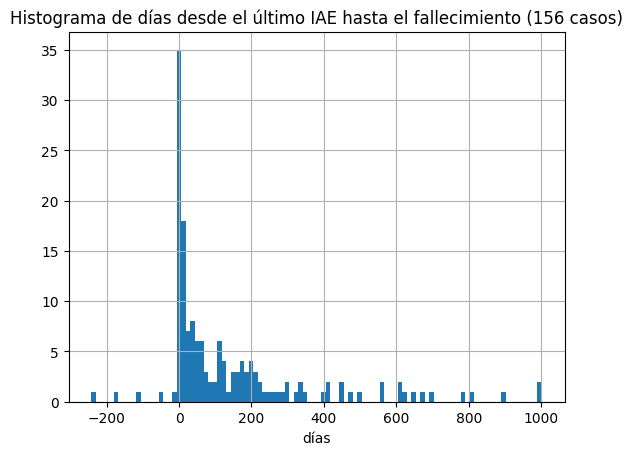

In [788]:
plt.figure()
df_IAE_agregada[df_IAE_agregada['CAT_SUI_']==1]['MIN_DIAS_IAE_MUERTE_'].dt.days.hist(bins=100)
n_casos = df_IAE_agregada[df_IAE_agregada['CAT_SUI_']==1]['MIN_DIAS_IAE_MUERTE_'].value_counts().sum()
plt.title(f'Histograma de días desde el último IAE hasta el fallecimiento ({n_casos} casos)')
plt.xlabel('días')
plt.show()

In [789]:
#indices = df_IAE_agregada['CEDULA'].isin(df_IAE_CDE['cedula'])
#f_IAE_agregada[~indices].shape 

personas_con_IAE_no_presentes_en_CDE(df_IAE_agregada, df_IAE_CDE)

Hay 11987 personas con IAE no presentes en CDE.


,CEDULA,Sexo,NACIMIENTO,GRUPO_EDAD_,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2_,METODO_IAE_PREVIO_3_,IAE_PREVIO,PRESTADOR_RECODIFICADO,...,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,SHARPS_,SIV_,ANTIPOLIOMELITICA,COVID 19
0,0000e681952be7f20878a73707231609bf41c5c8c0a86b...,None,NaT,NaN,Otros,Otros,None,None,NO SE INDICA,ASSE - HOSPITAL DE CLINICAS,...,True,False,UY,TACUAREMBO,TACUAREMBO,Fonasa,0,1,NaN,3.0
1,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,17.5,Lesiones autoinfligidas,Lesiones autoinfligidas,None,None,SI,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,...,False,True,UY,TREINTA Y TRES,TREINTA Y TRES,Fonasa,0,1,4.0,NaN
2,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,32.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,SI,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,...,None,None,None,None,None,None,1,1,NaN,4.0
4,00127d6bb76d70724ef073fe967dd80f6b77df38a959ae...,Femenino,2004-07-01,22.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO SE INDICA,AMDM IAMPP - ASISTENCIAL MEDICA DEPARTAMENTAL ...,...,False,True,UY,MALDONADO,MALDONADO,No Fonasa,0,1,4.0,NaN
5,00133099d10f0d6d56bd2f58267ff271fd097b1682638f...,Femenino,2007-03-01,17.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO,ASSE - MALDONADO /DIRECCION NACIONAL DE SANIDA...,...,True,False,UY,ARTIGAS,BELLA UNION,Fonasa,0,1,4.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16660,ffdda04d9cb7f61ac16abefb57d895d41381e70cc5098d...,Femenino,1998-04-01,27.5,Ahorcamiento o asfixia,Ahorcamiento o asfixia,None,None,NO,ASSE - PAYSANDU,...,True,False,UY,PAYSANDU,PORVENIR,No Fonasa,0,1,4.0,2.0
16661,ffe42d723da45d0e54737c67fccc747dcc8aceb73075fb...,Femenino,2009-05-01,17.5,Lesiones autoinfligidas,Lesiones autoinfligidas,None,None,SI,COMERO,...,False,True,UY,ROCHA,ROCHA,Fonasa,0,1,4.0,1.0
16662,fff6eeeb39dc05fc78a98f367f478045ccf8835a538565...,Masculino,1965-11-01,57.5,Ingesta de Medicamentos,Ingesta de Medicamentos,Ingesta de Medicamentos,None,NO,CASMU,...,False,True,UY,MONTEVIDEO,MONTEVIDEO,Fonasa,0,0,NaN,NaN
16663,fff70f241b7a38806c1580fb5d8077c97d84bc6256b0ae...,Femenino,1995-07-01,27.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO,ASSE - SD,...,None,None,None,None,None,None,0,1,NaN,NaN


In [790]:
indices = df_IAE_CDE['cedula'].isin(df_IAE_agregada['CEDULA'])
personas = df_IAE_CDE[~indices]

In [791]:
personas_en_CDE_sin_IAE(df_IAE_agregada, df_IAE_CDE)

Hay 0 personas en CDE que no están en la base de IAE.


,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,estado_civil,etnia,mayor_nivel_educacion,institucion_fallecio,es_motivo_externo,motivo_externo,motivo_externo_desc,CAT_SUI_,CAT_MCEXSUI_,grupo edades_


In [792]:
df_IAE_agregada[df_IAE_agregada['PRESTADOR_PUBLICO_']==1]['IAE_en_CDE_'].value_counts()

IAE_en_CDE_
0    5294
1     176
Name: count, dtype: int64

In [793]:
if dataset==2:
    indices = df_IAE_agregada['CEDULA'].isin(df_IAE_EH['cedula'])
    df_IAE_agregada[~indices].shape 

In [794]:
df_IAE_agregada[df_IAE_agregada['MIN_DIAS_IAE_MUERTE_']< pd.Timedelta(days=0)]

,CEDULA,Sexo,NACIMIENTO,GRUPO_EDAD_,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2_,METODO_IAE_PREVIO_3_,IAE_PREVIO,PRESTADOR_RECODIFICADO,...,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,SHARPS_,SIV_,ANTIPOLIOMELITICA,COVID 19
176,02b6dcc5b9fbe88bbd4cfd6e3ccd8dcffde35c0123562b...,Masculino,1976-11-01,47.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO SE INDICA,ASSE - CANELONES PANDO,...,None,None,None,None,None,None,0,1,NaN,4.0
1551,17d7693dafc5a08d2b7e7e141b5e5a216acebffedb5843...,Femenino,1966-02-01,57.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO SE INDICA,ASSE - CHUY,...,None,None,None,None,None,None,0,0,NaN,NaN
2075,1fdf2df0248db1754d1881db0f2b65bbeb9ff67a4f3db2...,Masculino,1939-08-01,82.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO,CRAME | ASSE - ADMINISTRACION DE SERVICIOS DE ...,...,None,None,None,None,None,None,0,1,NaN,4.0
3408,34baa9c7eea3c9094845ad75e09fbf4416364a084d7cbc...,Masculino,1976-12-01,47.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO,CRAME,...,None,None,None,None,None,None,0,1,NaN,3.0
5504,554642d2e11e26e9aebf1ec22cff12e09baf1cf58f1c55...,Masculino,1967-10-01,57.5,Ingesta de Medicamentos,Otros,Ingesta de Medicamentos,None,SI,ASSE - ROCHA,...,None,None,None,None,None,None,0,1,NaN,3.0
9000,8a9ae7a9e78922906915d3488e422349262c914e51ba7f...,Masculino,1965-01-01,57.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO SE INDICA,COMEPA,...,None,None,None,None,None,None,0,1,NaN,4.0
10974,a99e2c600a984570577790d9e5f0dc33de9ed3c88f41d0...,Femenino,1947-03-01,77.5,Ingesta de Medicamentos,Ingesta de Medicamentos,Ingesta de Medicamentos,None,SI,CAMS IAMPP - CENTRO ASISTENCIAL MEDICO DE SORI...,...,None,None,None,None,None,None,0,1,NaN,4.0
10977,a9ac507b3c929bf7996676adc22950c1de8e395b47ebd3...,Masculino,1976-01-01,47.5,Otros,Otros,None,None,NO SE INDICA,CRAMI IAMPP,...,None,None,None,None,None,None,0,1,NaN,2.0
11585,b34581ab07195735e0c068ea596911835217ad6d418260...,Femenino,1958-09-01,67.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,SI,ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS,...,None,None,None,None,None,None,0,1,NaN,4.0
13746,d3c855d00efebdc82eb4e58a1bb26c8b7e9e9e10eb1d74...,Masculino,1992-03-01,32.5,Lesiones autoinfligidas,Lesiones autoinfligidas,None,None,SI,"ASSE - CHUY // ROCHA, LASCANO",...,None,None,None,None,None,None,0,1,4.0,2.0


In [795]:
df_IAE_agregada['IAE_en_CDE_'].value_counts()

IAE_en_CDE_
0    11987
1     4678
Name: count, dtype: int64

In [796]:
df_IAE_agregada.set_index('FECHA_DEFUNCION').resample('W').size()

FECHA_DEFUNCION
2023-01-01     7
2023-01-08    35
2023-01-15    26
2023-01-22    29
2023-01-29    38
              ..
2026-01-11     4
2026-01-18     7
2026-01-25     2
2026-02-01     4
2026-02-08     1
Length: 163, dtype: int64

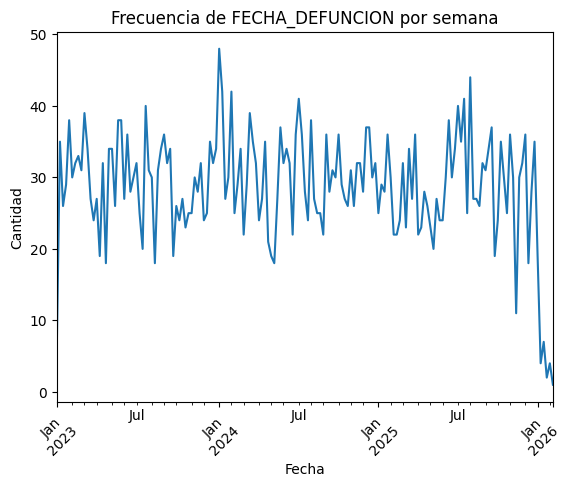

In [797]:
if dataset==2:
    #conteo_semanal_defunciones = df_IAE_agregada[df_IAE_agregada['CAT_SUI_']==1].set_index('FECHA_DEFUNCION').resample('W').size()

    #plt.figure()
    #conteo_semanal_defunciones.plot()
    #plt.xlabel("Fecha")
    #plt.ylabel("Cantidad")
    #plt.title("Cantidad de fallecimientos por semana")
    #plt.xticks(rotation=45)
    #plt.show()

    graficar_segun_fecha(df_IAE_agregada,'FECHA_DEFUNCION','W')

In [798]:
df_IAE_agregada.head()

,CEDULA,Sexo,NACIMIENTO,GRUPO_EDAD_,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2_,METODO_IAE_PREVIO_3_,IAE_PREVIO,PRESTADOR_RECODIFICADO,...,RUCAF_PRESTADOR_PUBLICO_,RUCAF_PRESTADOR_PRIVADO_,RUCAF_pais,RUCAF_departamento,RUCAF_localidad,RUCAF_cobertura,SHARPS_,SIV_,ANTIPOLIOMELITICA,COVID 19
0,0000e681952be7f20878a73707231609bf41c5c8c0a86b...,None,NaT,NaN,Otros,Otros,None,None,NO SE INDICA,ASSE - HOSPITAL DE CLINICAS,...,True,False,UY,TACUAREMBO,TACUAREMBO,Fonasa,0,1,NaN,3.0
1,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,17.5,Lesiones autoinfligidas,Lesiones autoinfligidas,None,None,SI,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,...,False,True,UY,TREINTA Y TRES,TREINTA Y TRES,Fonasa,0,1,4.0,NaN
2,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,32.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,SI,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,...,None,None,None,None,None,None,1,1,NaN,4.0
3,0004278339f5f72aa648112ee2ea5968932e11d34147aa...,Masculino,NaT,NaN,Ahorcamiento o asfixia,Ahorcamiento o asfixia,None,None,NO SE INDICA,None,...,None,None,None,None,None,None,0,1,1.0,2.0
4,00127d6bb76d70724ef073fe967dd80f6b77df38a959ae...,Femenino,2004-07-01,22.5,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO SE INDICA,AMDM IAMPP - ASISTENCIAL MEDICA DEPARTAMENTAL ...,...,False,True,UY,MALDONADO,MALDONADO,No Fonasa,0,1,4.0,NaN


In [799]:
#df_IAE_agregada['DIAS_PROMEDIO_INTENTOS_'].unique()
mostrar_unicos(df_IAE_agregada,'DIAS_PROMEDIO_INTENTOS_')

DIAS_PROMEDIO_INTENTOS_ tiene 839 valores únicos.
[           nan 2.77500000e+01 1.65000000e+02 2.50000000e+01
 2.56500000e+02 2.48000000e+02 3.28000000e+02 1.31200000e+02
 2.27500000e+02 6.35000000e+01 2.70000000e+02 4.60000000e+02
 6.90000000e+02 1.26000000e+02 1.00000000e+02 1.10000000e+01
 1.45000000e+01 6.30000000e+01 2.05000000e+02 3.86500000e+02
 8.00000000e+00 1.60000000e+02 0.00000000e+00 3.70000000e+01
 2.90000000e+01 2.17000000e+02 4.46000000e+02 5.20000000e+01
 4.50000000e+01 1.00000000e+00 3.60000000e+02 2.18000000e+02
 3.35000000e+02 1.20000000e+02 7.00000000e+00 2.55000000e+02
 3.60000000e+01 3.66000000e+02 3.13500000e+02 4.28000000e+02
 4.20000000e+01 3.10500000e+02 1.85000000e+02 5.14000000e+02
 1.15666667e+02 2.49000000e+02 3.80000000e+02 7.40000000e+01
 8.17000000e+02 7.09000000e+02 2.79000000e+02 4.65000000e+01
 3.12000000e+02 2.61000000e+02 2.00500000e+02 4.35000000e+02
 1.74000000e+02 1.59000000e+02 1.65000000e+01 1.70000000e+02
 9.00000000e+00 2.16000000e+02 1.05

In [800]:
np.sum(df_IAE_agregada['IAE_en_CDE_']==1)

np.int64(4678)

In [801]:
# Cuadro 2A en el informe
df_IAE_agregada['NUMERO_INTENTOS_'].value_counts()

NUMERO_INTENTOS_
1     10313
0      4286
2      1445
3       392
4       112
5        54
6        21
7        19
9         9
8         5
10        3
13        2
12        2
11        1
16        1
Name: count, dtype: int64

In [802]:
mostrar_frecuencias(df_IAE_agregada, 'IAE_PREVIO')

IAE_PREVIO
NO SE INDICA    6611
SI              5654
NO              4309
Tratamiento       91
Name: count, dtype: int64


In [803]:
#df_IAE_agregada['IAE_PREVIO_CORREGIDO' ] = df_IAE_agregada['IAE_PREVIO'].copy()
#df_IAE_agregada.loc[(df_IAE_agregada["IAE_PREVIO_CORREGIDO"] == "NO SE INDICA") & (df_IAE_agregada["NUMERO_INTENTOS_"] > 0), "IAE_PREVIO_CORREGIDO"] = "SI"

df_IAE_agregada = agregar_IAE_PREVIO_corregido(df_IAE_agregada)

In [804]:
df_IAE['IAE PREVIO'].shape, df_IAE_agregada['IAE_PREVIO'].shape

((19871,), (16665,))

In [805]:
df_IAE['IAE PREVIO'].value_counts().sum()

np.int64(19871)

In [806]:
df_IAE_agregada['IAE_PREVIO'].value_counts().sum()

np.int64(16665)

In [807]:
df_IAE_agregada['IAE_PREVIO_CORREGIDO'].value_counts()

IAE_PREVIO_CORREGIDO
NO SE INDICA    6345
SI              5920
NO              4309
Tratamiento       91
Name: count, dtype: int64

In [808]:
df_IAE_agregada.loc[df_IAE_agregada['IAE_PREVIO']=='NO SE INDICA', 'IAE_en_CDE_'].value_counts()

IAE_en_CDE_
1    4384
0    2227
Name: count, dtype: int64

In [809]:
df_IAE_agregada.loc[df_IAE_agregada['IAE_PREVIO']=='NO SE INDICA', 'NUMERO_INTENTOS_'].value_counts()

NUMERO_INTENTOS_
0    4285
1    2060
2     195
3      46
4      16
5       4
6       3
7       2
Name: count, dtype: int64

In [810]:
df_IAE_agregada.loc[df_IAE_agregada['IAE_PREVIO_CORREGIDO']=='NO SE INDICA', 'IAE_en_CDE_'].value_counts()

IAE_en_CDE_
1    4370
0    1975
Name: count, dtype: int64

In [811]:
df_IAE_agregada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16665 entries, 0 to 16664
Data columns (total 71 columns):
 #   Column                                       Non-Null Count  Dtype          
---  ------                                       --------------  -----          
 0   CEDULA                                       16665 non-null  object         
 1   Sexo                                         16355 non-null  object         
 2   NACIMIENTO                                   12060 non-null  datetime64[ns] 
 3   GRUPO_EDAD_                                  12059 non-null  float64        
 4   METODO_IAE_FRECUENTE_                        16665 non-null  object         
 5   METODO_IAE_PREVIO_                           16665 non-null  object         
 6   METODO_IAE_PREVIO_2_                         2067 non-null   object         
 7   METODO_IAE_PREVIO_3_                         621 non-null    object         
 8   IAE_PREVIO                                   16665 non-null  objec

In [812]:
for atributo in df_IAE_agregada.keys():
    mostrar_valores_nulos(df_IAE_agregada,atributo)
    mostrar_unicos(df_IAE_agregada,atributo)
    mostrar_frecuencias(df_IAE_agregada,atributo)

CEDULA tiene 0 valores nulos
CEDULA tiene 16665 valores únicos.
['0000e681952be7f20878a73707231609bf41c5c8c0a86b0166da88d7ebd012ba'
 '0003596f1bde95098ff48b86d0561cb0498b93576221e33bb3da1bf5fabf0ee2'
 '00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db8d78c72df7ea548a22' ...
 'fff6eeeb39dc05fc78a98f367f478045ccf8835a538565f47ba0949106157136'
 'fff70f241b7a38806c1580fb5d8077c97d84bc6256b0aefb96ce7f4d04b484c2'
 'fff9a612ad60860b9c3be2ca6b24e6d338b2a8f62b11f7602b4f14707c32dfd5']
CEDULA
fff9a612ad60860b9c3be2ca6b24e6d338b2a8f62b11f7602b4f14707c32dfd5    1
0000e681952be7f20878a73707231609bf41c5c8c0a86b0166da88d7ebd012ba    1
0003596f1bde95098ff48b86d0561cb0498b93576221e33bb3da1bf5fabf0ee2    1
00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db8d78c72df7ea548a22    1
0004278339f5f72aa648112ee2ea5968932e11d34147aa171f5934009af1bb2e    1
                                                                   ..
0032097781d6234e08d6d3034d49bb174722254cc33215ddd67c82882f686cfc    1
0031f4cbece0e9c8eed9edf2c2

In [813]:
#for atributo in df_IAE_agregada.keys():
#    if 'FECHA' in atributo or 'REGISTRO' == atributo:
#        mostrar_rango(df_IAE_agregada,atributo)

## Guardar la base de datos agregada por persona

In [814]:
nombre_procesada = f'IAE_agregada_entrega{dataset}_{timestamp}.csv' 
df_IAE_agregada.to_csv(nombre_procesada)